# 0. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
from sklearn.model_selection import train_test_split
import random
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from config import config

In [3]:
np.random.seed(config.seed)
random.seed(config.seed)
torch.manual_seed(config.seed)

In [4]:
# generator для Даталоудера
g = torch.Generator()
g.manual_seed(config.seed)

In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

# 1. Intro

a. Describe the types of tasks for which recurrent neural networks are useful.
- для задач анализа данных, где есть временная компонента (текст, звук, временные ряды);
- за счет появление концепции вектора скрытого состояния RNN на каждом следующем шаге обработки способны использовать информацию о предыдущих токенах;
- обрабатывают данные поэлементно;
- основные области задач: обработка последовательностей и временных зависимостей, задачи с переменной длиной входа и выхода, задачи NLP/NLP+CV, генерация последовательностей.

b. Give 2 examples of one-to-many, many-to-many, and many-to-one formulations of the problem.

- one-to-many (на входе 1 объект, на выходе последовательность): генерация музыки по жанру-строке, генерация текста по заданной теме; предсказание структуры молекулы по заданному вектору свойств (набору дескрипторов).

- many-to-many (входная последовательность синхронно или асинхронно порождает выходную, длины могут отличаться): задача перевода звука в текст и наоборот; задача выявления отдельных источников звука на аудиозаписи; машинный перевод, суммаризация текста; генерация подписи к изображению.

- many-to-one (на входе последовательность, на выходе 1 объект): классификация писем на основе содержания как спам/не спам; анализ настроения отзывов; прогнозирование финансовых рынков; диагностика кардиозаболеваний по ЭКГ; классификация организмов по генам; предсказание генов устойчивости к болезням; обнаружение модификаций в ДНК при секвенировании.

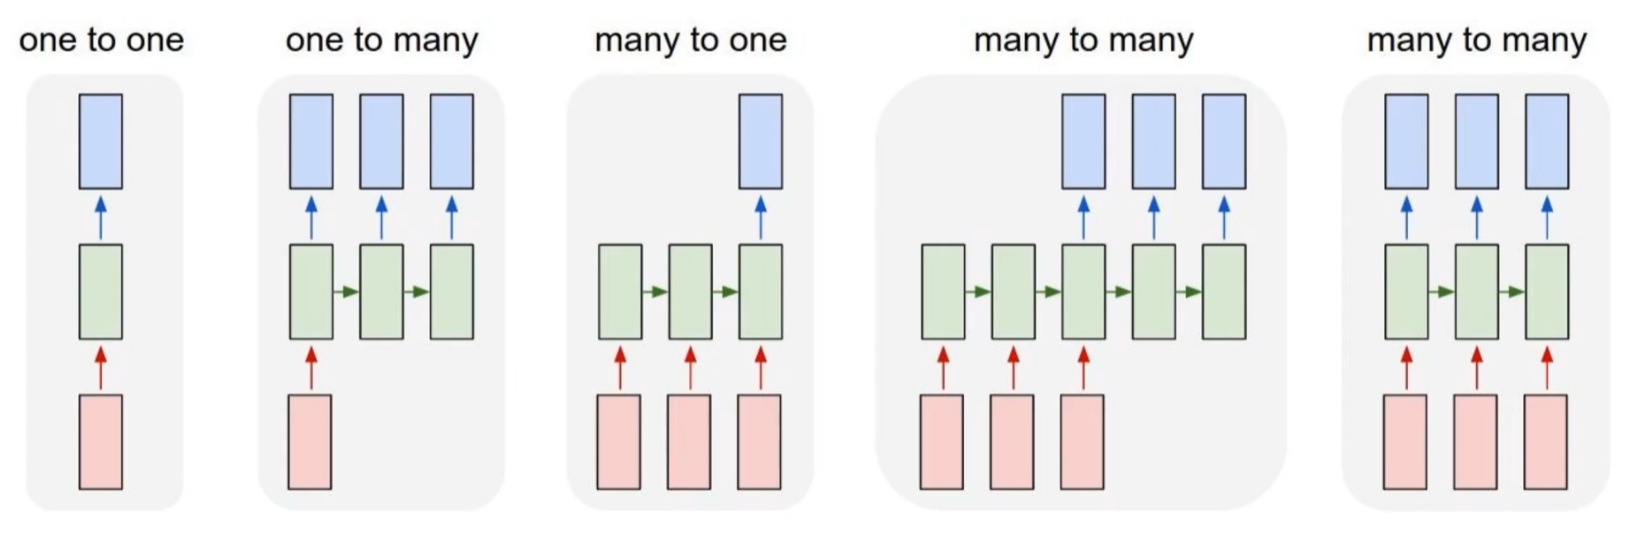

c. Imagine you have an RNN that classifies the language of incoming words. Illustrate (in Paint, Drawio, etc.) with blocks how this model will process the word "Hello". Draw each input and output. Define each block with its parameters. Illustrate what the initial value of the hidden state will be.
- В задаче "many-to-one" промежуточный аутпут не вычисляется (или вычисляется, но не используется). Аутпут вычисляется на последнем шаге с использованием последнего скрытого состояния (h6), которое содержит информацию о всех токенах входящей последовательности ("SOS" - start of sequence, "EOS" - end of sequence)
- Формула для обновления скрытого слоя:

$h_t = \text{tanh}(W \cdot X_t + U \cdot h_{t-1} + b_h)$

- Формула для итогового выхода (например, пусть будет сигмоида):

$y_t = \text{sigma}(W_y \cdot h_t + b_y)$

- Способы инициализации h0:
1) нули;
2) random (добавить случайный шум);
3) обучаемая инициализация (преобразование входного вектора X0 в вектор начального состояния);
4) в архитектурах Stateful RNN - инициализируют скрытым состоянием от предыдущего батча;
5) в архитектурах seq2seq инициализация финальным состоянием энкодера.

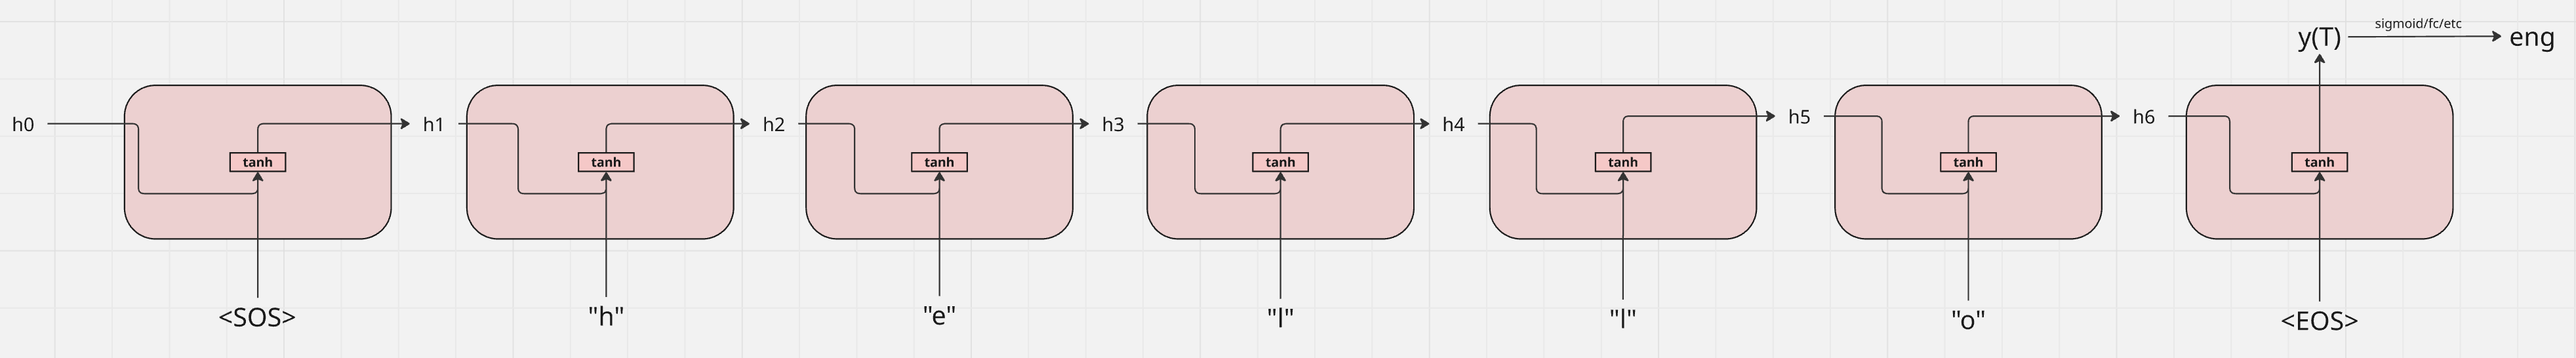

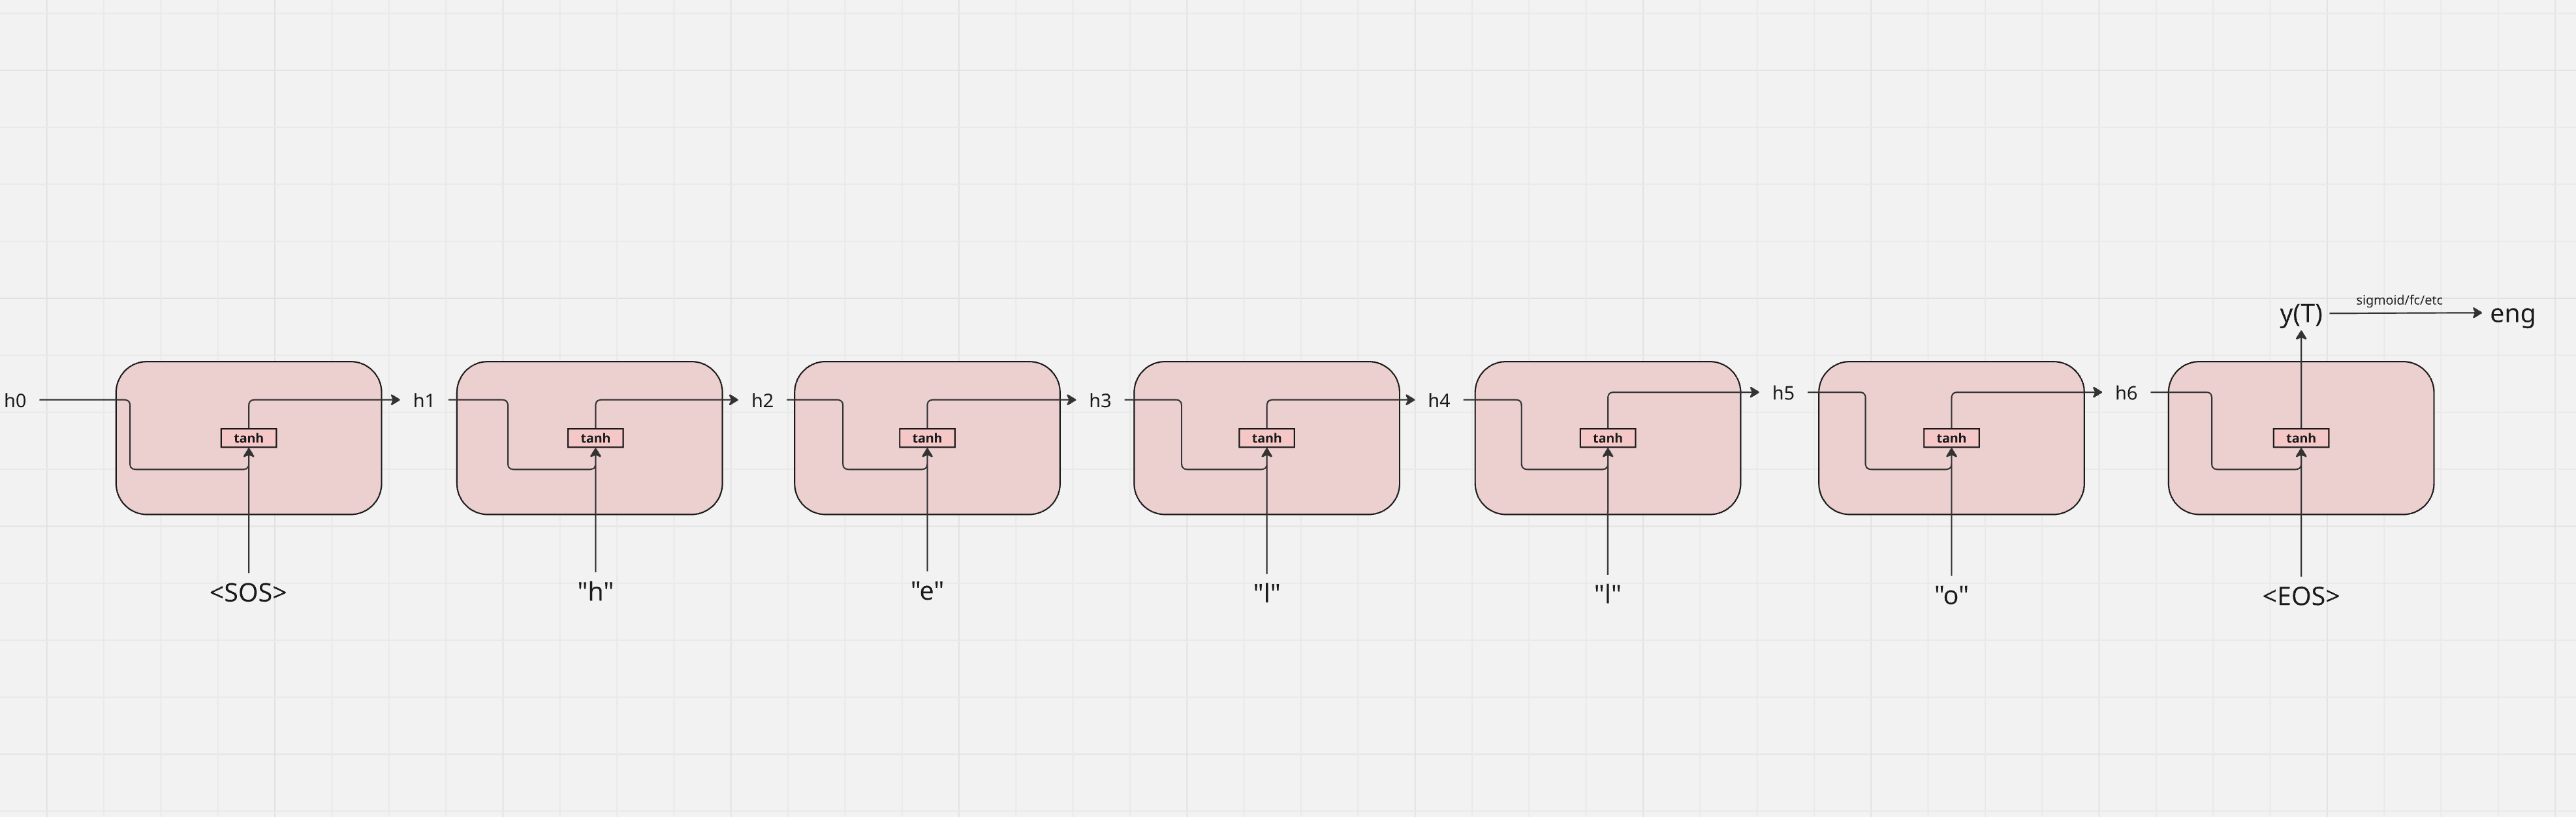

d. Explain the main difference between vanilla RNN, LSTM, and GRU. Draw LSTM or GRU similar to RNN.

**Классическая RNN (Vanilla)**
- имеет 1 вектор скрытого состояния (h), формулы для обновления h и получения y  со слоя:

$$h_t = \text{tanh}(W \cdot X_t + U \cdot h_{t-1} + b_h)$$


$$Y_t = \text{sigma}(W_y \cdot h_t + b_y)$$

где $W$ - матрица весов для входа, $U$ - матрица весов для предыдущего скрытого состояния, $b_h$, $b_y$ - соответствующие смещения. Для получения выхода может использоваться не только сигмоида, но и любая функция активации или же следовать полносвязный слой.

У функции tanh градиенты на краях маленькие > могут затухать при обратном распространении во времени. Кроме того, при развертывании RNN градиенты умножаются на одни и те же матрицы весов много раз, что может приводить либо к затуханию (если собств значения матриц < 1), либо к взрыву (если > 1). Для преодоления проблемы затухания градиентов разработаны специальные усложненные архитектуры - GRU и LSTM. В сеть добавляют специальные ворота (gate), имитирующие процессы забывания и запоминания (добавление/удаление информации с определенными коэффициентами), которые обеспечивают более стабильное распространение градиентов, хотя и не решают полностью проблему затухания ввиду ограничений памяти скрытого слоя и сложности обучения ворот.

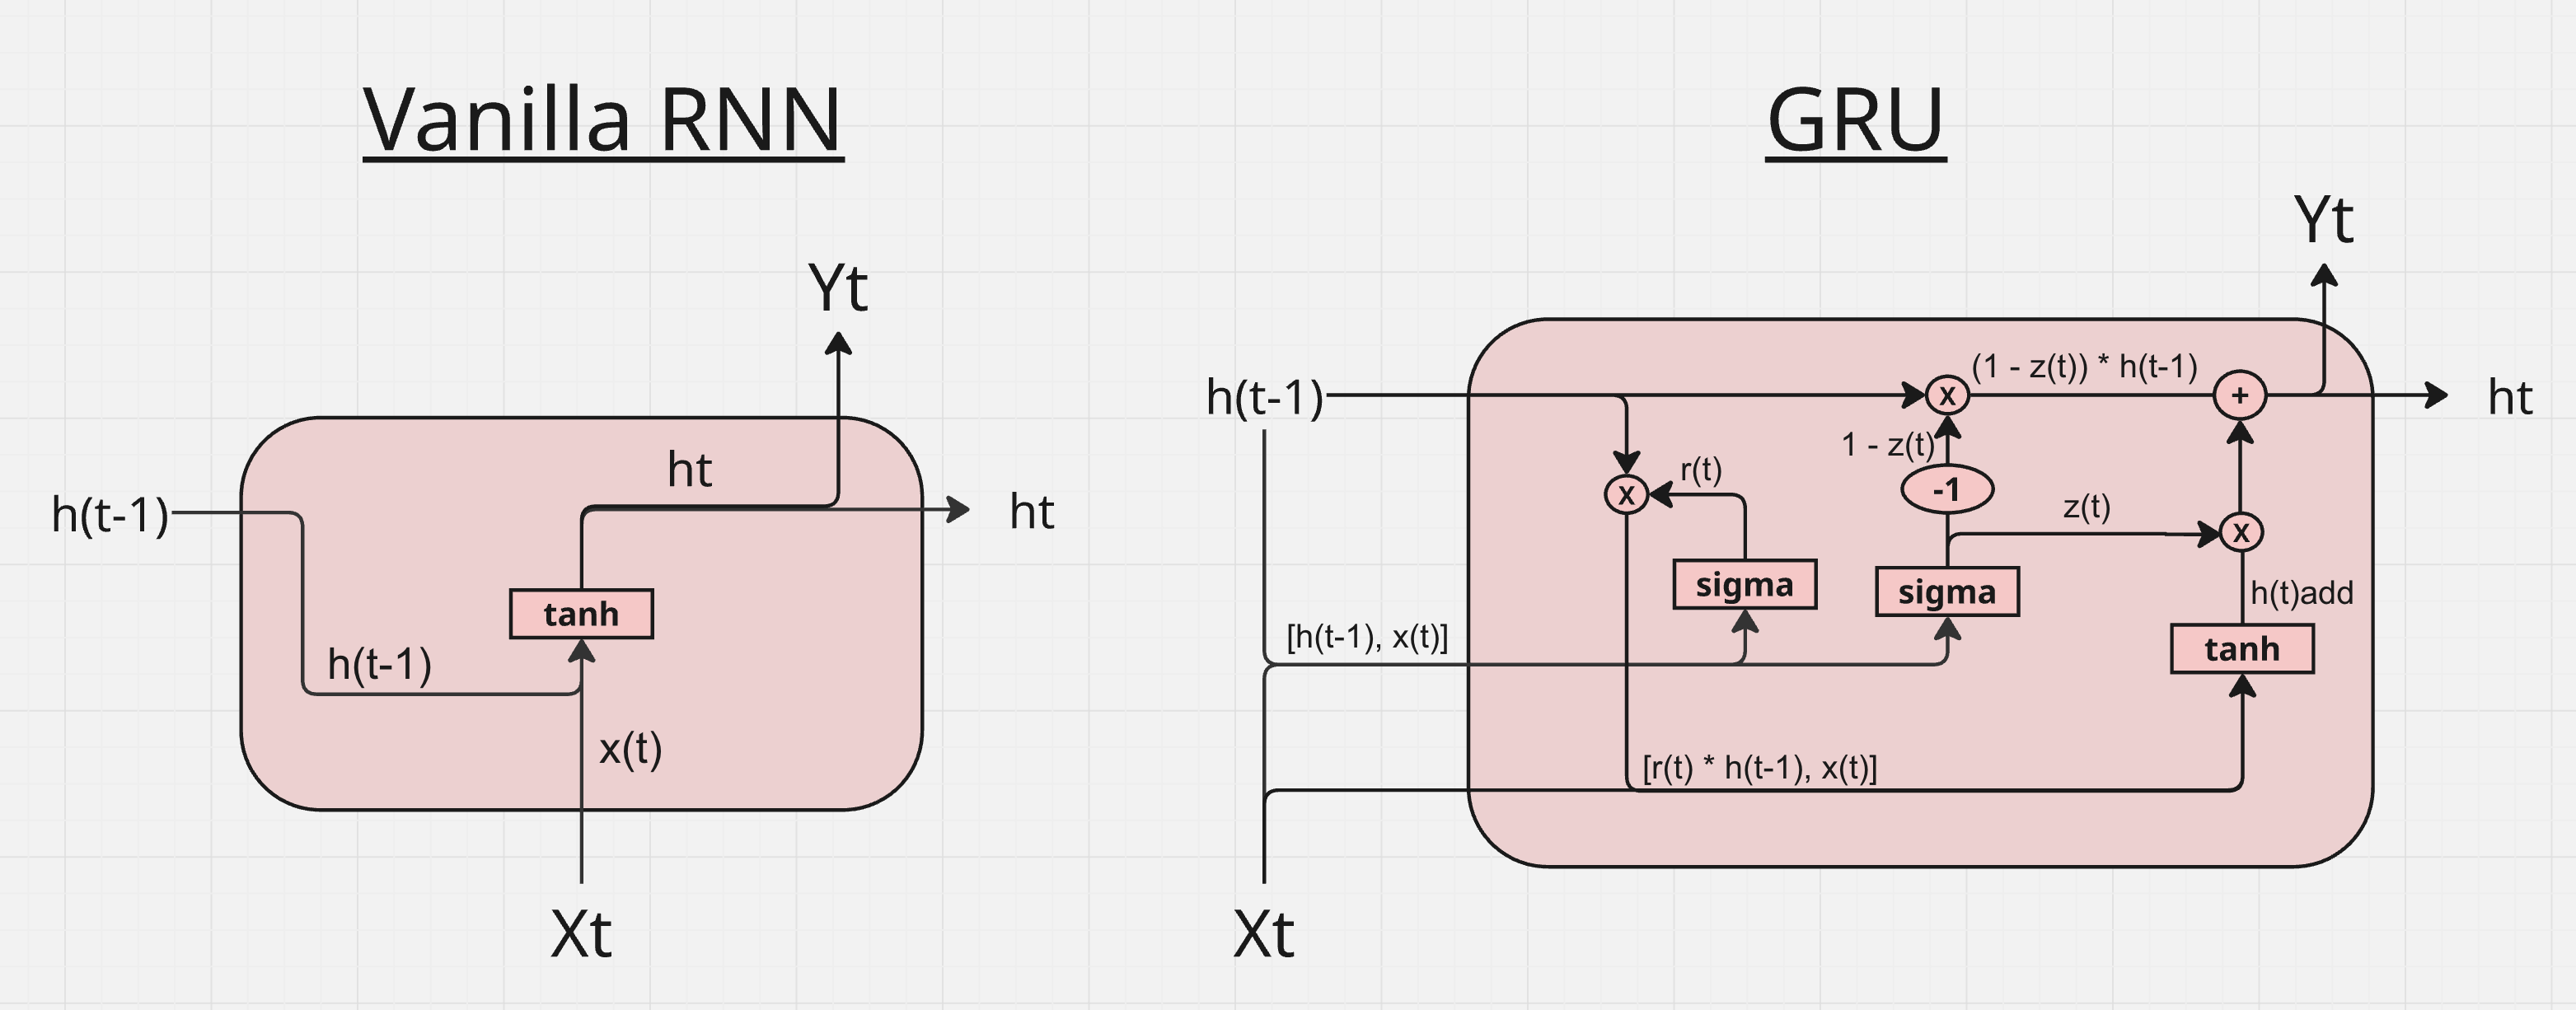

**GRU (Gated Recurrent Unit)**
- следующая по сложности после стандартной RNN. Добавлены 2 ворот: ворота обновления ($z_t$) и ворота сброса ($r_t$). Формулы обновления:

$$r_t = \sigma(W_r \cdot [h_{t-1}, X_t] + b_r)$$

$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t]) + b_z)$$

$$h_t^{\text{add}} = \text{tanh}(W \cdot [r_t \cdot h_{t-1}, x_t])$$

$$h_t = (1-z_t) \cdot h_{t-1} + z_t \cdot h_t^{\text{add}})$$

- Здесь стабилизация градиентов достигается за счет двух механизмов: линейной интерполяции скрытого состояния и адаптивного управления воротами.

1) Добавление линейности:
- Финальное обновление вектора скрытого состояния происходит с участием слагаемого (1-$z_t$) * $h_{t-1}$ - то есть прямой линейной связи между скрытым состоянием предыдущего шага, без нелинейных преобразований. Линейная интерполяция создает возможность для градиентов течь не затухая: если $z_t$ близок к 0, то градиент практически без изменений переходит в $h_{t-1}$.

2) Адаптивное управление воротами:
-  Ворота обновления $z_t$  определяют, насколько сильно обновлять состояние. Если сеть решает, что текущий вход не важен, она может установить его
близким к 0, и тогда состояние почти не меняется и информация сохраняется надолго.

- Ворота сброса $r_t$ влияет на вычисление скрытого состояния. Они позволяют игнорировать нерелевантное прошлое при формировании $h_t$, но не оказывает прямого влияния на поток градиентов через $h_{t-1}$. Здесь затухание возможно (далее $r_t \cdot h_{t-1}$ идет в tanh), но оно регулируемо (перемножением с $z_t$).


**LSTM (Long Term Short Memory)**
-  наиболее сложная архитектура, тяжелая по памяти и вычислительной емкости; однако менее всего подвержена забыванию контекста;
- добавлен ВТОРОЙ скрытый слой $C_t$ - ячейку состояния, аналог "долговременной" памяти в контексте ее функционирования;

Формулы:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

$$C_t^{\text{temp}} = f_t \cdot C_{t-1}$$

$$C_t^{\text{add}} = \text{tanh}(W_c \cdot [h_{t-1}, x_t] + b_c)$$

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$

$$C_t = C_t^{\text{temp}} + i_t \cdot C_t^{\text{add}} = f_t \cdot C_{t-1} + i_t \cdot C_t^{\text{add}}$$

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

$$h_t = o_t \cdot \text{tanh}(C_t)$$

$$y_t = \sigma(W_y \cdot h_t + b_y)$$

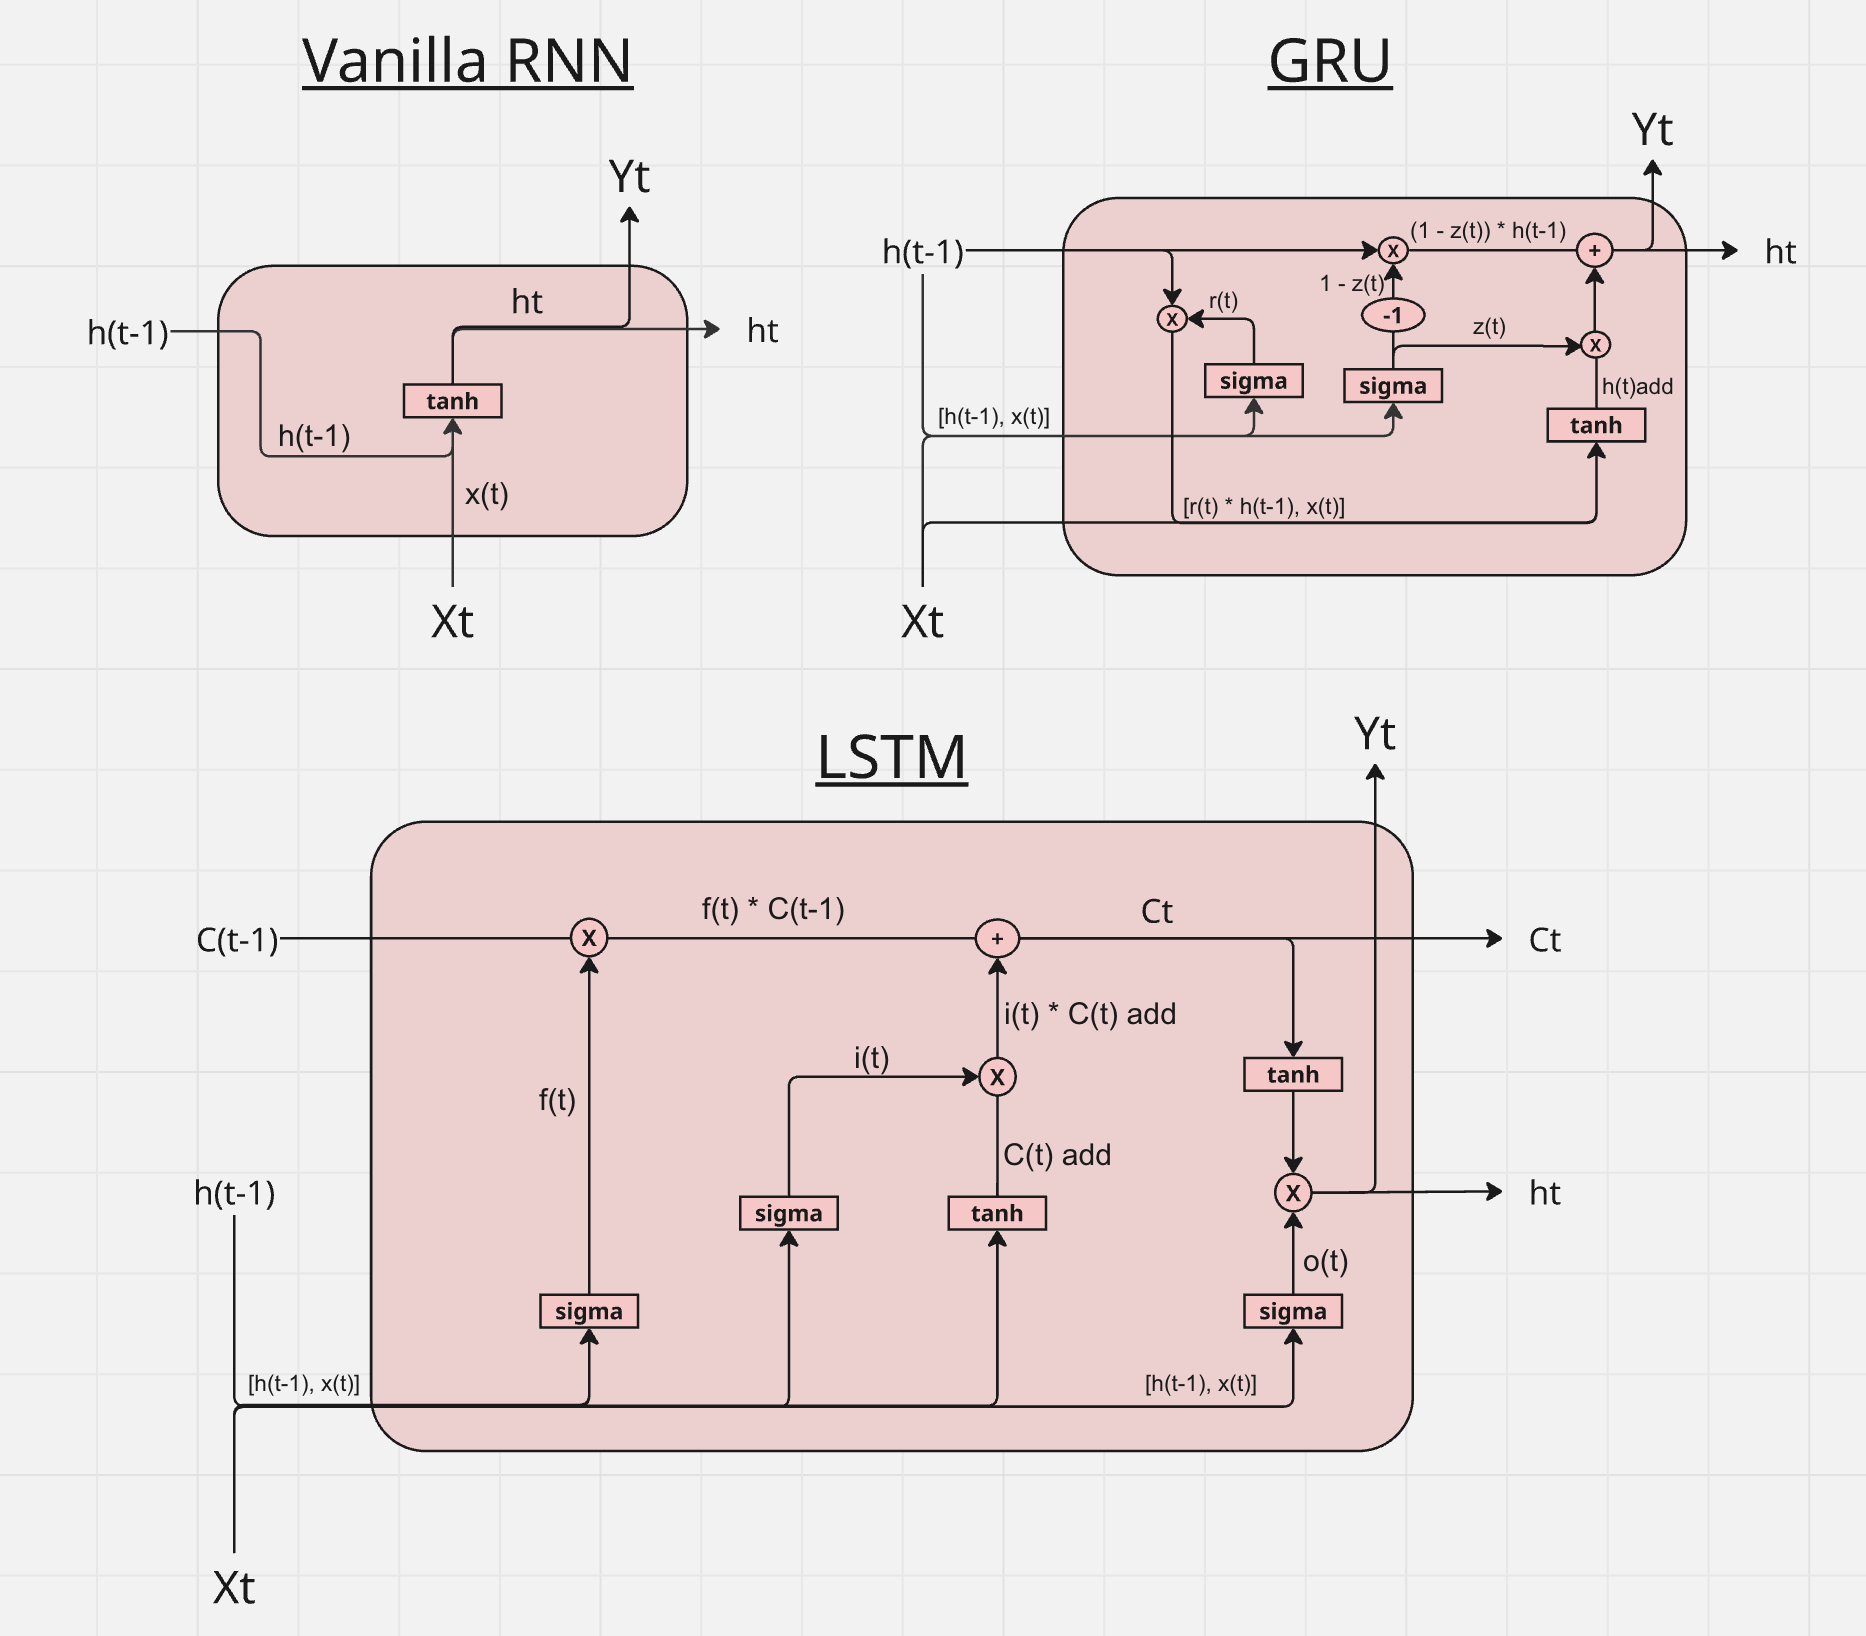

1) Стабилизация градиентов благодаря линейной рекуррентности в ячейке состояния $C_t$:

$$C_t = f_t \cdot C_{t-1} + i_t \cdot C_t^{\text{add}}$$

т.е. $C_t$ считается как линейная комбинация старого состояния, умноженного на забывающий коэффициент $f_t$ и нового состояния с коэффициентом $i_t$.

2) Адаптация ворот:
- $f_t$ - ворота забывания, главный инструмент для сохранения долговременной памяти. Когда они открыты (~1), старая информация сохраняется.

- $i_t$ - ворота входа, добавляют новую информацию, но не мешает потоку градиентов через $C_t$.


- $o_t$ - ворота выхода, отделяют состояние ячейки от скрытого состояния, что позволяет хранить в $C_t$ информацию, даже если она не нужна на выходе прямо сейчас.

В целом, LSTM архитектура являлась стандартом для многих задач с последовательностями до появления трансформеров.

# 2. Data Analysis

a. Download the dataset from the link above or from the course files.

In [21]:
!gdown 1O40Hi3XL7nf1INVrtsCGcTHVcI9360hJ # baby_names.csv

Downloading...
From: https://drive.google.com/uc?id=1O40Hi3XL7nf1INVrtsCGcTHVcI9360hJ
To: /content/babynames-clean.csv
100% 84.2k/84.2k [00:00<00:00, 86.9MB/s]


In [22]:
name_data = pd.read_csv("/content/babynames-clean.csv", header=0, names=["Name", "Gender"])
name_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6781 entries, 0 to 6780
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    6781 non-null   object
 1   Gender  6781 non-null   object
dtypes: object(2)
memory usage: 106.1+ KB


b. Plot a histogram of name lengths.

<Axes: xlabel='Name', ylabel='Count'>

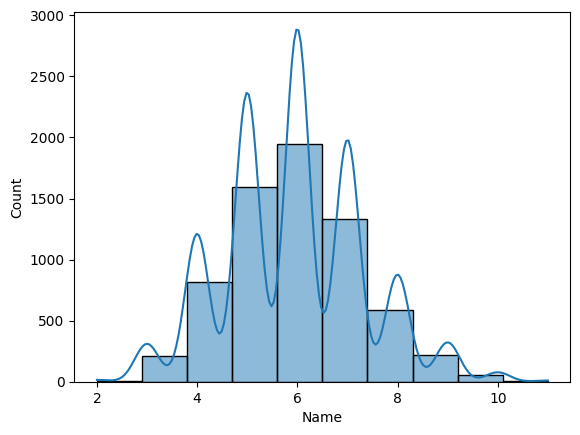

In [23]:
sns.histplot(data=name_data, x=name_data["Name"].str.len(), kde=True, bins=10)

c. Check if the dataset is gender balanced or not.

In [24]:
boy_count = name_data[name_data["Gender"]=="boy"].count()
girl_count = name_data[name_data["Gender"]=="girl"].count()
print(f"Boys: {boy_count}\n")
print(f"Girls: {girl_count}")
# apprx balanced

Boys: Name      3436
Gender    3436
dtype: int64

Girls: Name      3345
Gender    3345
dtype: int64


d. Count the frequency of each letter.

In [25]:
all_letters = (letter for row in name_data.itertuples(index=False) for letter in row[0].lower()) # generator
letter_counts = Counter(all_letters)
letter_counts = dict(sorted(letter_counts.items()))
letter_counts

{'a': 5593,
 'b': 673,
 'c': 1063,
 'd': 1532,
 'e': 5038,
 'f': 302,
 'g': 526,
 'h': 1205,
 'i': 3264,
 'j': 501,
 'k': 616,
 'l': 3255,
 'm': 1245,
 'n': 3523,
 'o': 2070,
 'p': 265,
 'q': 61,
 'r': 3070,
 's': 1674,
 't': 1745,
 'u': 707,
 'v': 490,
 'w': 271,
 'x': 71,
 'y': 1243,
 'z': 199}

# 3. Data preparation

a. Encode gender.

In [26]:
name_data["Gender"].unique()

array(['boy', 'girl'], dtype=object)

In [27]:
gender_to_label = {"boy": 0, "girl": 1}
name_data["Gender"] = name_data["Gender"].astype(str).map(gender_to_label)

b. Convert names to lowercase.

In [28]:
name_data["Name"] = name_data["Name"].str.lower()

c. Extend each name with 'start of name' prefix (e.g. <SOS>), 'end of name' postfix (e.g. <EOS>) and pad the name with 'space' (e.g. ' ') up to the maximum length.

In [29]:
name_data["Tokens"] = name_data['Name'].apply(lambda s: ['<SOS>'] + list(s) + ['<EOS>'])
max_len = name_data["Tokens"].str.len().max()
name_data['Padded_tokens'] = name_data['Tokens'].apply(lambda tokens: tokens + [' '] * (max_len - len(tokens)))

In [30]:
name_data.tail()

,Name,Gender,Tokens,Padded_tokens
6776,laylah,1,"[<SOS>, l, a, y, l, a, h, <EOS>]","[<SOS>, l, a, y, l, a, h, <EOS>, , , , , ]"
6777,carleigh,1,"[<SOS>, c, a, r, l, e, i, g, h, <EOS>]","[<SOS>, c, a, r, l, e, i, g, h, <EOS>, , , ]"
6778,kenley,1,"[<SOS>, k, e, n, l, e, y, <EOS>]","[<SOS>, k, e, n, l, e, y, <EOS>, , , , , ]"
6779,sloane,1,"[<SOS>, s, l, o, a, n, e, <EOS>]","[<SOS>, s, l, o, a, n, e, <EOS>, , , , , ]"
6780,elianna,1,"[<SOS>, e, l, i, a, n, n, a, <EOS>]","[<SOS>, e, l, i, a, n, n, a, <EOS>, , , , ]"


d. Create the array of tokens (letters and special symbols) that will be used to encode each name. Create a mapping from token to integer id and vice versa.

In [31]:
alphabet_dict = {char: index for index, char in enumerate(string.ascii_lowercase, 1)}
alphabet_dict["<SOS>"] = 27
alphabet_dict["<EOS>"] = 28
alphabet_dict[" "] = 0
alphabet_dict = dict(sorted(alphabet_dict.items(), key=lambda item: item[1]))
alphabet_dict

{' ': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '<SOS>': 27,
 '<EOS>': 28}

e. Represent each name as a sequence of integers using the mapping from D. Each sequence should have the same length.

In [32]:
name_data["Name_to_id"] = name_data["Padded_tokens"].apply(lambda s: [alphabet_dict[ch] for ch in s])

In [33]:
name_data.head()

,Name,Gender,Tokens,Padded_tokens,Name_to_id
0,william,0,"[<SOS>, w, i, l, l, i, a, m, <EOS>]","[<SOS>, w, i, l, l, i, a, m, <EOS>, , , , ]","[27, 23, 9, 12, 12, 9, 1, 13, 28, 0, 0, 0, 0]"
1,james,0,"[<SOS>, j, a, m, e, s, <EOS>]","[<SOS>, j, a, m, e, s, <EOS>, , , , , , ]","[27, 10, 1, 13, 5, 19, 28, 0, 0, 0, 0, 0, 0]"
2,charles,0,"[<SOS>, c, h, a, r, l, e, s, <EOS>]","[<SOS>, c, h, a, r, l, e, s, <EOS>, , , , ]","[27, 3, 8, 1, 18, 12, 5, 19, 28, 0, 0, 0, 0]"
3,george,0,"[<SOS>, g, e, o, r, g, e, <EOS>]","[<SOS>, g, e, o, r, g, e, <EOS>, , , , , ]","[27, 7, 5, 15, 18, 7, 5, 28, 0, 0, 0, 0, 0]"
4,frank,0,"[<SOS>, f, r, a, n, k, <EOS>]","[<SOS>, f, r, a, n, k, <EOS>, , , , , , ]","[27, 6, 18, 1, 14, 11, 28, 0, 0, 0, 0, 0, 0]"


f. Split the dataset into training, valid, and test parts (take 80-10-10%). Be sure to use random_state.

In [34]:
train_val, test_data = train_test_split(name_data[["Name_to_id", "Gender"]],
                                   test_size=0.2,
                                   random_state=21,
                                   stratify=name_data["Gender"])

train_data, valid_data = train_test_split(train_val,
                                   test_size=0.5,
                                   random_state=21,
                                   stratify=train_val["Gender"])

In [35]:
print(train_data.shape)
print(valid_data.shape)
print(test_data.shape)
test_data.head()

(2712, 2)
(2712, 2)
(1357, 2)


,Name_to_id,Gender
2718,"[27, 12, 1, 19, 8, 1, 23, 14, 28, 0, 0, 0, 0]",0
6684,"[27, 11, 9, 14, 19, 12, 5, 25, 28, 0, 0, 0, 0]",1
6426,"[27, 13, 1, 3, 9, 28, 0, 0, 0, 0, 0, 0, 0]",1
3818,"[27, 3, 12, 1, 18, 9, 3, 5, 28, 0, 0, 0, 0]",1
5426,"[27, 11, 1, 18, 9, 28, 0, 0, 0, 0, 0, 0, 0]",1


# 4. Recurrent Neural Network

## a. Implement a network that contains:

- Embedding layer;
- Vanilla recurrent neural network block (do not use already implemented blocks from libraries, expect to implement this block from scratch);
- Linear layer to transform the output of the RNN block into logits of the next token output;
- Linear layer to transform the last token output of the RNN block to logit of gender;
- You can also add a dropout layer if you want;
- Sigmoid to transform the gender class logit to probability;
- Don't forget to implement a method to initialize the hidden state.

In [45]:
class MyVanillaRNN(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(MyVanillaRNN, self).__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size

    self.input_weights = nn.Parameter(torch.Tensor(input_size, hidden_size))
    self.hidden_weights = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
    self.h_bias = nn.Parameter(torch.Tensor(hidden_size))
    self.layer_norm = nn.LayerNorm(hidden_size) #

    nn.init.xavier_uniform_(self.input_weights)
    nn.init.xavier_uniform_(self.hidden_weights)
    nn.init.orthogonal_(self.hidden_weights)
    nn.init.zeros_(self.h_bias)


  def forward(self, x, h=None):
    # X (batch, seq_len, input_size)
    batch_size, seq_len, _ = x.shape
    if h is None:
      h = self.__init_hidden__(x)

    x = x.transpose(0, 1)  # (seq_len, batch, input_size)
    outputs = []

    for t in range(seq_len):
      # токен на шаге t: форма (batch_size, input_size)
      x_t = x[t]
      input_part = x_t @ self.input_weights
      hidden_part = h @ self.hidden_weights

      h = torch.tanh(input_part + hidden_part  + self.h_bias)
      h = self.layer_norm(h) # norm-n
      outputs.append(h)

    outputs = torch.stack(outputs, dim=1)
    return outputs, h

  def __init_hidden__(self, x):
    batch_size = x.shape[0]
    return torch.zeros(batch_size, self.hidden_size, device=x.device)

In [46]:
class NameGeneratorClassifier(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size, dropout_prob, rnn_class=MyVanillaRNN, **rnn_kwargs):
    super(NameGeneratorClassifier, self).__init__()
    self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
    self.rnn = rnn_class(embed_dim, hidden_size,**rnn_kwargs)
    self.dropout = nn.Dropout(dropout_prob)
    #self.dropout_emb = nn.Dropout(p=0.2)
    self.layer_norm = nn.LayerNorm(hidden_size)

    # linear: RNN output >> logits of next token
    self.next_token_fc = nn.Linear(hidden_size, vocab_size)

    # linear: RNN output >> logits gender (binary class)
    self.gender_fc = nn.Linear(hidden_size, 1)

  def forward(self, x, hidden=None):
    emb = self.embedding(x) # (batch_size, seq_len, emb_dim)
    #emb = self.dropout_emb(emb)
    outputs, last_hidden = self.rnn(emb, hidden)

    if isinstance(last_hidden, tuple):          # пайторч LSTM: (h_n, c_n)
        last_hidden = last_hidden[0][-1]        # h_n последнего слоя
    elif last_hidden.dim() == 3:                # пайторч GRU
        last_hidden = last_hidden[-1]

    # norm-n
    outputs = self.layer_norm(outputs)
    last_hidden = self.layer_norm(last_hidden)

    # dropoutt
    outputs = self.dropout(outputs)
    last_hidden_dropped = self.dropout(last_hidden)

    next_token_logits = self.next_token_fc(outputs)
    # outputs: (batch, seq_len, hidden) > (batch_size, seq_len-1, vocab_size)
    # -1 bc кроме последнего [:, :-1, :]

    gender_logit = self.gender_fc(last_hidden_dropped)
    # (batch, hidden_size)  > (batch, 1)

    # sigmoid gender logit > prob  (batch, 1)
    gender_prob = torch.sigmoid(gender_logit)

    return next_token_logits, gender_prob


##b. Train the network using only loss for next letter prediction:

- Take the output of the softmax layer for each token in sequence except the last.
- Take the next token as label.
- Compute the cross-entropy loss and perform a backward step.

### help functions

In [39]:
class NameDataset(Dataset):
  def __init__(self, sequences, genders):
    self.sequences = torch.tensor(sequences, dtype=torch.long)
    self.genders = torch.tensor(genders, dtype=torch.float32).unsqueeze(1)  # (n,1)

  def __len__(self):
    return len(self.sequences)

  def __getitem__(self, idx):
    return self.sequences[idx], self.genders[idx]

In [40]:
def create_datasets(train, valid, test):
  X_train = np.array(train["Name_to_id"].tolist())
  X_valid = np.array(valid["Name_to_id"].tolist())
  X_test = np.array(test["Name_to_id"].tolist())

  Y_train = train["Gender"].values
  Y_valid = valid["Gender"].values
  Y_test = test["Gender"].values

  train_dataset = NameDataset(X_train, Y_train)
  valid_dataset = NameDataset(X_valid, Y_valid)
  test_dataset = NameDataset(X_test, Y_test)

  return train_dataset, valid_dataset, test_dataset

### task

In [41]:
def prepare_batch(mode, criterion, letter_logits, gender_prob, batch_seq, batch_gender, device):

    if mode == "letter":
        logits_flat = letter_logits[:, :-1, :].reshape(-1, letter_logits.size(-1))
        targets_flat = batch_seq[:, 1:].reshape(-1)

        if isinstance(criterion, torch.nn.CrossEntropyLoss):
            return logits_flat, targets_flat
        elif isinstance(criterion, torch.nn.NLLLoss):
            return torch.log_softmax(logits_flat, dim=-1), targets_flat
        else:
            raise ValueError(f"Unsupported criterion for mode 'letter': {type(criterion)}")

    else:  # mode == "gender"

        target_float = batch_gender.float()
        if target_float.dim() == 1:
            target_float = target_float.unsqueeze(-1)  # (batch, 1)
        target_long = batch_gender.squeeze(-1).long()   # (batch,)

        if isinstance(criterion, torch.nn.CrossEntropyLoss):
            eps = 1e-7
            p = gender_prob.squeeze(-1).clamp(eps, 1 - eps)
            logit_pos = torch.log(p / (1 - p))
            logit_neg = torch.zeros_like(logit_pos)                  # (batch,)
            input_tensor = torch.stack([logit_neg, logit_pos], dim=1) # (batch, 2)
            return input_tensor, target_long

        elif isinstance(criterion, torch.nn.NLLLoss):
            eps = 1e-7
            p = gender_prob.squeeze(-1).clamp(eps, 1 - eps)          # (batch,)
            input_tensor = torch.stack([torch.log(1 - p), torch.log(p)], dim=1) # (batch, 2)
            return input_tensor, target_long

        elif isinstance(criterion, torch.nn.BCELoss):
            return gender_prob, target_float

        else:
            raise ValueError(f"Unsupported criterion for mode 'gender': {type(criterion)}")

In [42]:
def train_val_loop(model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler=None, mode="letter"):
    train_losses, val_losses = [], []
    device = config.device
    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0
        num_batches = 0

        for batch_seq, batch_gender in train_loader:
            batch_seq = batch_seq.to(device)
            if mode == "gender":
                batch_gender = batch_gender.to(device)

            optimizer.zero_grad()
            letter_logits, gender_prob = model(batch_seq)  # gender_prob уже после sigmoid

            input_tensor, target_tensor = prepare_batch(mode, criterion, letter_logits, gender_prob, batch_seq, batch_gender, device)

            loss = criterion(input_tensor, target_tensor)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item()
            num_batches += 1

        avg_train_loss = total_train_loss / num_batches
        train_losses.append(avg_train_loss)


        model.eval()
        total_val_loss = 0.0
        num_batches = 0

        with torch.no_grad():
            for batch_seq, batch_gender in val_loader:
                batch_seq = batch_seq.to(device)
                if mode == "gender":
                    batch_gender = batch_gender.to(device)

                letter_logits, gender_prob = model(batch_seq)

                input_tensor, target_tensor = prepare_batch(
                    mode, criterion, letter_logits, gender_prob, batch_seq, batch_gender, device
                )

                loss = criterion(input_tensor, target_tensor)
                total_val_loss += loss.item()
                num_batches += 1

        avg_val_loss = total_val_loss / num_batches
        val_losses.append(avg_val_loss)

        if scheduler is not None:
            scheduler.step(avg_val_loss)

        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    plt.figure(figsize=(10,5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss convergence')
    plt.legend()
    plt.grid(True)
    plt.show()

    return train_losses, val_losses

In [43]:
train_dataset, valid_dataset, test_dataset = create_datasets(train_data, valid_data, test_data)
train_loader = DataLoader(train_dataset, config.batch_size, shuffle=True, generator=g)
val_loader = DataLoader(valid_dataset, config.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, config.batch_size, shuffle=False)

Epoch 1/10 | Train Loss: 1.6426 | Val Loss: 1.3337
Epoch 2/10 | Train Loss: 1.3214 | Val Loss: 1.2815
Epoch 3/10 | Train Loss: 1.2717 | Val Loss: 1.2526
Epoch 4/10 | Train Loss: 1.2460 | Val Loss: 1.2372
Epoch 5/10 | Train Loss: 1.2273 | Val Loss: 1.2265
Epoch 6/10 | Train Loss: 1.2036 | Val Loss: 1.2189
Epoch 7/10 | Train Loss: 1.1907 | Val Loss: 1.2138
Epoch 8/10 | Train Loss: 1.1761 | Val Loss: 1.2084
Epoch 9/10 | Train Loss: 1.1621 | Val Loss: 1.2021
Epoch 10/10 | Train Loss: 1.1510 | Val Loss: 1.1987


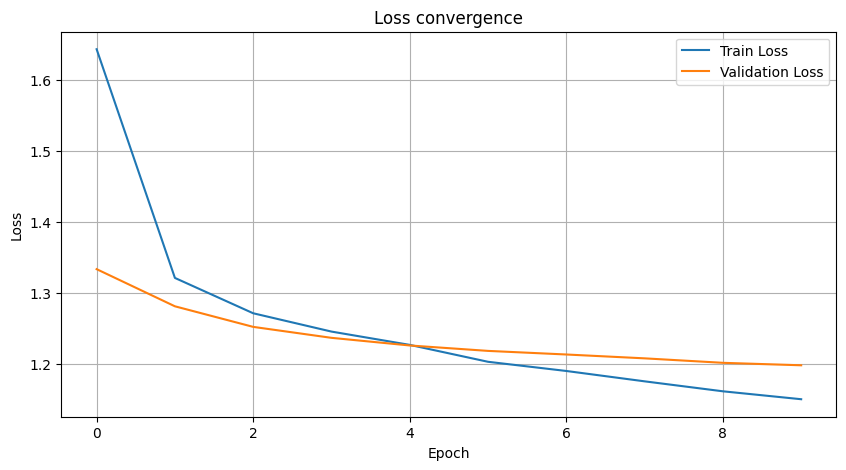

In [60]:
set_seed(21)
vrnn_model = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyVanillaRNN)

criterion = nn.CrossEntropyLoss(reduction='mean')
optimizer = torch.optim.AdamW(vrnn_model.parameters(),  lr=config.lr, weight_decay=config.weight_decay)

train_losses, val_losses = train_val_loop(vrnn_model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

## c. Implement a method to generate names from the trained model:

- Method should be stochastic — i.e. next letter should be sampled using probabilities based on logit level.
- Provide the parameter to control the beginning of the name.
- Specify the parameter to control the stochasticity of the next letter. Usually this parameter is called **temperature** (from physics).
- Higher temperature produces more chaotic outputs, lower temperature converges to the single most likely output.
- probs = softmax(logits / temperature, dim=-1)

In [48]:
from torch.nn.functional import softmax

def generate_names(model, alphabet_dict, prefix=None, temperature=0, random_state=21):

  device = config.device
  max_length = 15
  model.eval()
  start = 27
  stop = 28
  id_to_char = {v: k for k, v in alphabet_dict.items()}

  if (prefix is None) or (prefix == ""):
    prefix = np.array([start])
  else:
    mapped_prefix = list(map(lambda ch: [alphabet_dict[ch]], prefix.lower()))
    mapped_prefix = [[start]] + mapped_prefix
    prefix = np.array(mapped_prefix).squeeze() # abz > [27,  1,  2, 26]

  # numpy > list
  generated_ids = prefix.tolist()

  input_prefix = torch.from_numpy(prefix).unsqueeze(0).to(device) # (batch_size=1, seq_len)

  g = torch.Generator(device=device)
  if random_state is not None:
    torch.manual_seed(random_state)
    g.manual_seed(random_state)

  with torch.no_grad():
    for _ in range(max_length):
      next_token_logits, _ = model.forward(input_prefix) # (1, seq_len-1, vocab_size=29)
      last_step_probs = next_token_logits[0, -1, :] # 0 batch elem, last logits, vocab

      if temperature == 0:
        next_token = torch.argmax(last_step_probs).item()
      else:
        temp_probs = softmax((last_step_probs / temperature), dim=-1)
        next_token = torch.multinomial(temp_probs, 1, generator=g).item()

      generated_ids.append(next_token)

      if next_token == stop: # "<EOS>"
        break

      input_prefix = torch.tensor([generated_ids], dtype=torch.long, device=device)

  name_tokens = []
  for token_id in generated_ids:
        if token_id == start:
            continue
        if token_id == stop:
            break
        name_tokens.append(id_to_char[token_id])

  generated_name = ''.join(name_tokens)
  return generated_name

In [49]:
pr = generate_names(vrnn_model, alphabet_dict, prefix="", temperature=0.1)

## d. Evaluation

- Plot loss convergence on train and valid data. - см. выше, в ходе обучения.
- Sample 10 names. Are they realistic? (Remember to put the model in eval mode.)

In [50]:
def new_names(model):
  prefix_list = ["a", "mi", "el", "ar", "di", "ra", "em"]
  new_names = []
  for prefix in prefix_list:
    name = generate_names(model, alphabet_dict, prefix, temperature=0.3)
    new_names.append(name)
  return new_names

In [61]:
v_rnn_list = new_names(vrnn_model)
v_rnn_list

['arile', 'mila', 'eliana', 'arissa', 'dianne', 'rayda', 'emarie']

- Predict the gender of the names from the test data and compute the ROC AUC score.

In [53]:
from sklearn.metrics import roc_auc_score


def calc_roc_auc(model, test_loader):
  model.eval()
  all_gender_probs = []
  all_true_genders = []
  device = config.device

  with torch.no_grad():
      for batch_seq, batch_gender in test_loader:
          batch_seq = batch_seq.to(device)
          batch_gender = batch_gender.to(device)

          _, gender_prob = model(batch_seq)  #(batch, 1)

          all_gender_probs.append(gender_prob.cpu().numpy())
          all_true_genders.append(batch_gender.cpu().numpy())

  y_probs = np.concatenate(all_gender_probs).ravel()
  y_true = np.concatenate(all_true_genders).ravel()

  roc_auc = roc_auc_score(y_true, y_probs)
  print(f"Test ROC AUC: {roc_auc:.4f}")
  return roc_auc

In [62]:
vanilla_rnn_roc_auc = calc_roc_auc(vrnn_model, test_loader)

Test ROC AUC: 0.5730


# 5. GRU

Repeat steps 4.a, 4.b, and 4.d, but with the GRU model as the recurrent neural network block.

In [55]:
class MyGRU(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(MyGRU, self).__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size

    self.linear_r = nn.Linear(input_size + hidden_size, hidden_size)
    self.linear_z = nn.Linear(input_size + hidden_size, hidden_size)

    # for h
    self.W_in = nn.Linear(input_size, hidden_size, bias=False)
    self.W_hn = nn.Linear(hidden_size, hidden_size, bias=False)
    self.b_in = nn.Parameter(torch.zeros(hidden_size))
    self.b_hn = nn.Parameter(torch.zeros(hidden_size))

    self._init_weights()

  def forward(self, x, h=None):
    # X (batch, seq_len, input_size)
    batch_size, seq_len, _ = x.shape
    if h is None:
      h = self.__init_hidden__(x)

    outputs = []

    for t in range(seq_len):
      x_t = x[:, t, :]  # (batch, input_size)
      common_input = torch.cat([x_t, h], dim=1) # (batch, input_size+hidden_size)
      r = torch.sigmoid(self.linear_r(common_input)) # (batch, hidden)
      z = torch.sigmoid(self.linear_z(common_input))  # (batch, hidden)

      #n = torch.tanh(self.W_in(x_t) + r * self.W_hn(h) + self.b_n)  # (batch, hidden)
      n = torch.tanh(self.W_in(x_t) + self.b_in + r * (self.W_hn(h) + self.b_hn))
      #h = (1 - z) * n + z * h  # (batch, hidden)
      h = z * n + (1 - z) * h
      outputs.append(h)

    outputs = torch.stack(outputs, dim=1) # (batch, seq_len, hidden)
    return outputs, h

  def __init_hidden__(self, x):
    batch_size = x.shape[0]
    return torch.zeros(batch_size, self.hidden_size, device=x.device)

  def _init_weights(self):
    for name, param in self.named_parameters():
      if 'weight' in name:
        nn.init.xavier_uniform_(param)
      elif 'bias' in name:
        nn.init.zeros_(param)

Epoch 1/10 | Train Loss: 1.5444 | Val Loss: 1.3235
Epoch 2/10 | Train Loss: 1.3143 | Val Loss: 1.2755
Epoch 3/10 | Train Loss: 1.2739 | Val Loss: 1.2551
Epoch 4/10 | Train Loss: 1.2559 | Val Loss: 1.2438
Epoch 5/10 | Train Loss: 1.2396 | Val Loss: 1.2340
Epoch 6/10 | Train Loss: 1.2280 | Val Loss: 1.2280
Epoch 7/10 | Train Loss: 1.2152 | Val Loss: 1.2256
Epoch 8/10 | Train Loss: 1.2144 | Val Loss: 1.2226
Epoch 9/10 | Train Loss: 1.2096 | Val Loss: 1.2191
Epoch 10/10 | Train Loss: 1.2035 | Val Loss: 1.2171


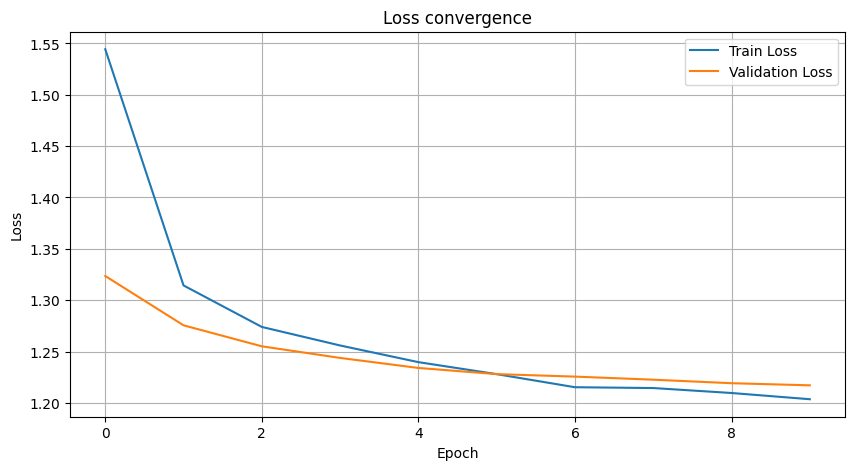

In [59]:
set_seed(21)
model_GRU = NameGeneratorClassifier(config.vocab_size,
                                    config.embed_dim,
                                    config.hidden_size,
                                    config.dropout_prob,
                                    rnn_class=MyGRU)


criterion = nn.CrossEntropyLoss(reduction='mean')

optimizer = torch.optim.Adam(model_GRU.parameters(), lr=config.lr, weight_decay=config.weight_decay)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=config.patience, factor=config.factor)

train_losses, val_losses = train_val_loop(model_GRU, train_loader, val_loader, criterion, optimizer, num_epochs=10, scheduler=scheduler)

In [57]:
gru_list = new_names(model_GRU)
gru_list

['arelle', 'mirley', 'ellia', 'arisa', 'dianne', 'raylee', 'emarle']

In [58]:
gru_roc_auc = calc_roc_auc(model_GRU, test_loader)

Test ROC AUC: 0.4015


# 6. LSTM

Repeat steps 4.a, 4.b, and 4.d, but with the LSTM model as the recurrent network block.

In [63]:
class MyLSTM(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(MyLSTM, self).__init__()
    set_seed(21)
    self.input_size = input_size
    self.hidden_size = hidden_size

    self.linear_f = nn.Linear(input_size + hidden_size, hidden_size)
    self.linear_i = nn.Linear(input_size + hidden_size, hidden_size)
    self.linear_o = nn.Linear(input_size + hidden_size, hidden_size)

    # for h
    self.W_in = nn.Linear(input_size, hidden_size, bias=False)
    self.W_hn = nn.Linear(hidden_size, hidden_size, bias=False)
    self.b_n = nn.Parameter(torch.zeros(hidden_size))


    self._init_weights()

  def forward(self, x, h=None, c=None):
    # X (batch, seq_len, input_size)
    batch_size, seq_len, _ = x.shape
    if h is None:
      h = torch.zeros(batch_size, self.hidden_size, device=x.device)
    if c is None:
      c = torch.zeros(batch_size, self.hidden_size, device=x.device)

    outputs = []

    for t in range(seq_len):
      x_t = x[:, t, :]  # (batch, input_size)
      common_input = torch.cat([x_t, h], dim=1) # (batch, input_size+hidden_size)
      f = torch.sigmoid(self.linear_f(common_input)) # (batch, hidden)
      i = torch.sigmoid(self.linear_i(common_input))  # (batch, hidden)

      c_temp = f * c
      c_add = torch.tanh(self.W_in(x_t) + self.W_hn(h) + self.b_n)  # (batch, hidden)
      c = c_temp + i * c_add

      o = torch.sigmoid(self.linear_o(common_input))
      h = o * torch.tanh(c)
      outputs.append(h)

    outputs = torch.stack(outputs, dim=1) # (batch, seq_len, hidden)
    return outputs, h

  def __init_hidden__(self, x):
    batch_size = x.shape[0]
    return torch.zeros(batch_size, self.hidden_size, device=x.device)

  def _init_weights(self):
    for name, param in self.named_parameters():
      if 'weight' in name:
        nn.init.xavier_uniform_(param)
      elif 'bias' in name:
        nn.init.zeros_(param)

Epoch 1/15 | Train Loss: 1.5601 | Val Loss: 1.3197
Epoch 2/15 | Train Loss: 1.3125 | Val Loss: 1.2735
Epoch 3/15 | Train Loss: 1.2772 | Val Loss: 1.2606
Epoch 4/15 | Train Loss: 1.2573 | Val Loss: 1.2480
Epoch 5/15 | Train Loss: 1.2483 | Val Loss: 1.2427
Epoch 6/15 | Train Loss: 1.2368 | Val Loss: 1.2342
Epoch 7/15 | Train Loss: 1.2278 | Val Loss: 1.2287
Epoch 8/15 | Train Loss: 1.2175 | Val Loss: 1.2278
Epoch 9/15 | Train Loss: 1.2149 | Val Loss: 1.2244
Epoch 10/15 | Train Loss: 1.2077 | Val Loss: 1.2223
Epoch 11/15 | Train Loss: 1.2081 | Val Loss: 1.2189
Epoch 12/15 | Train Loss: 1.2058 | Val Loss: 1.2169
Epoch 13/15 | Train Loss: 1.1999 | Val Loss: 1.2174
Epoch 14/15 | Train Loss: 1.2006 | Val Loss: 1.2163
Epoch 15/15 | Train Loss: 1.1977 | Val Loss: 1.2159


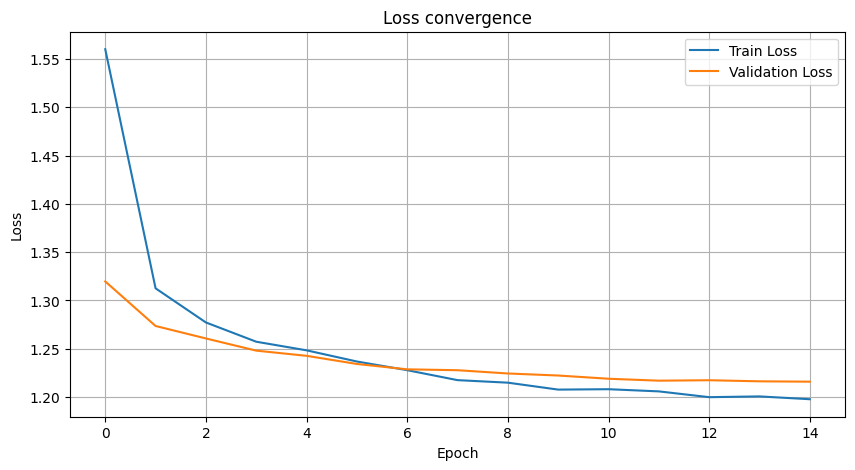

In [64]:
set_seed(21)
model_LSTM = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyLSTM)

criterion = nn.CrossEntropyLoss(reduction='mean')
optimizer = torch.optim.Adam(model_LSTM.parameters(), lr=config.lr, weight_decay=config.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=config.patience, factor=config.factor)

train_losses, val_losses = train_val_loop(model_LSTM, train_loader, val_loader, criterion, optimizer, num_epochs=15, scheduler=scheduler)

In [65]:
lstm_list = new_names(model_LSTM)
lstm_list

['arrie', 'mirrie', 'elisa', 'arrian', 'dirra', 'rayla', 'emarie']

In [66]:
lstm_roc_auc = calc_roc_auc(model_LSTM, test_loader)

Test ROC AUC: 0.2550


# 7. Model comparison

- Propose your own metric that can be used for name generator models. Please try to answer this question before reading the next one.

- Например, какое-нибудь accuracy@50 - доля предсказаний, где вероятность правильного следующего токена превышает 50%.

- Explain what perplexity measures.
- Derive how this metric is related to cross entropy loss.
- Implement 2 versions of this metric (with and without cross entropy loss).

**Perplexity** (перплексия) - метрика качества вероятностных моделей, которая показывает "уверенность" модели в предсказании. Численно равна экспоненте от среднего отрицательного логарифма вероятности правильных ответов. Чем меньше перплексия, тем лучше модель. (в идеале 1, в худшем случае = размер словаря).

$$W = (w_1, w_2, \dots, w_N)$$

$$ PPL(W) = \exp \left( -\frac{1}{N} \sum_{i=1}^N \log P(w_i | w_1, \dots, w_{i-1}) \right) $$

где:

$N$ - общее кол-во токенов в последовательности;

$P(w_i | w_1, \dots, w_{i-1})$ - вер-ть, которая модель присваивает правильному следующему токену

**Связь с кросс-энтропией**: тк кросс-энтропия = среднее отрицательное логарифмическое правдоподобие, то перплексия есть просто экспонента от кросс-энтропии.

$$ PPL = e^{H} $$

где $H$ - взвешенная кросс-энтропия модели по последовательности.

In [67]:
def ppl_v1(model, loader):
  device = next(model.parameters()).device
  criterion = nn.CrossEntropyLoss(reduction='mean')

  model.eval()
  total_loss = 0
  total_tokens = 0
  num_batches = 0
  with torch.no_grad():
      for batch_seq, _ in loader:
          batch_seq = batch_seq.to(device)
          logits, _ = model(batch_seq)
          loss = criterion(logits[:, :-1, :].reshape(-1, logits.size(-1)), batch_seq[:, 1:].reshape(-1))
          total_loss += loss.item()
          num_batches +=1
  avg_loss = total_loss / num_batches
  ppl = math.exp(avg_loss)
  print(f"Perplexity: {ppl:.4f}")
  return ppl

In [68]:
def ppl_v2(model, loader):

    model.eval()
    device = next(model.parameters()).device
    total_log = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch_seq, _ in loader:
            batch_seq = batch_seq.to(device) # (batch, seq_len)
            logits, _ = model(batch_seq) # (batch, seq_len, vocab)
            probs = torch.softmax(logits, dim=-1)
            targets = batch_seq[:, 1:] # (batch, seq_len-1)


            probs_correct = torch.gather(probs[:, :-1, :],dim=-1,index=targets.unsqueeze(-1)).squeeze(-1)
            # (batch, seq_len-1, 1) > # (batch, seq_len-1)

            log_probs = torch.log(probs_correct)
            total_log += log_probs.sum().item()
            total_tokens += log_probs.numel()

    avg_log = total_log / total_tokens
    ppl = math.exp(-avg_log)

    print(f"Perplexity: {ppl:.4f}")
    return ppl

- Derive the value of this metric for a "random" model that returns the same probability for each letter. Calculate the value of this metric in notebook.
- Для равномерной модели (которая предсказывает все токены равновероятно) перплексия равна размеру словаря.

In [69]:
total_tokens = len(alphabet_dict.values())
prob = 1/29
sum_log = total_tokens * math.log(1/29)
ppl = math.exp(- sum_log/total_tokens)
print(f"{ppl:.2f}") # equal to dict size

29.00


- Compute the value of this metric for a "most popular letters" model that returns the frequency of letters (the frequency of all letters should sum to 1).
- Для так называемой униграммной модели (предсказывает на тестовых данных каждый токен с вероятностью его встречаемости в тренировочных данных) перплексия получилась меньше размера словаря (тк у нас неравномерное распределение токенов), но больше, чем у хорошо обученной рекуррентной модели, тк рек модель учитывает контекст и может предсказывать токены точнее, опираясь на предыдущие символы.

In [70]:
all_letters_test = (letter for row in train_data.itertuples(index=False) for letter in row[0]) # generator
letter_counts = Counter(all_letters_test)
letter_counts = dict(sorted(letter_counts.items()))

valid_tokens = [tid for tid in letter_counts if tid not in (0, 27)]
total = sum(letter_counts[tid] for tid in valid_tokens)
prob_dict = {tid: letter_counts[tid] / total for tid in valid_tokens}

In [71]:
total_log = 0
total_count = 0
for batch_seq, _ in test_loader:
    targets = batch_seq[:, 1:]
    mask = (targets != config.pad_token_id)
    tokens = targets[mask].cpu().numpy()
    for t in tokens:
      if t in prob_dict:
        total_log += math.log(prob_dict[t])
        total_count += 1

ppl = math.exp(-total_log / total_count)
print(f"{ppl:.2f}")

17.11


- Compare the models.

In [72]:
vrnn_plp = ppl_v1(vrnn_model, test_loader)
gru_plp = ppl_v1(model_GRU, test_loader)
lstm_plp = ppl_v1(model_LSTM, test_loader)

Perplexity: 3.3061
Perplexity: 3.3652
Perplexity: 3.3696


In [73]:
vrnn_plp = ppl_v2(vrnn_model, test_loader)
gru_plp = ppl_v2(model_GRU, test_loader)
lstm_plp = ppl_v2(model_LSTM, test_loader)

Perplexity: 3.3062
Perplexity: 3.3639
Perplexity: 3.3691


# 8. Gender classification

## a. Let's train RNN, GRU, and LSTM, but with a different loss function:

- Take the probability of the gender class.
- Take the name gender as label.
- Compute the loss and do a backward step.
- Try the Binary Cross Entropy loss and the Negative Log Likelihood loss.
- Explain which loss is better and why.

Epoch 1/6 | Train Loss: 0.6185 | Val Loss: 0.4702
Epoch 2/6 | Train Loss: 0.4642 | Val Loss: 0.4196
Epoch 3/6 | Train Loss: 0.4014 | Val Loss: 0.4312
Epoch 4/6 | Train Loss: 0.3482 | Val Loss: 0.4792
Epoch 5/6 | Train Loss: 0.3045 | Val Loss: 0.4325
Epoch 6/6 | Train Loss: 0.2596 | Val Loss: 0.5026


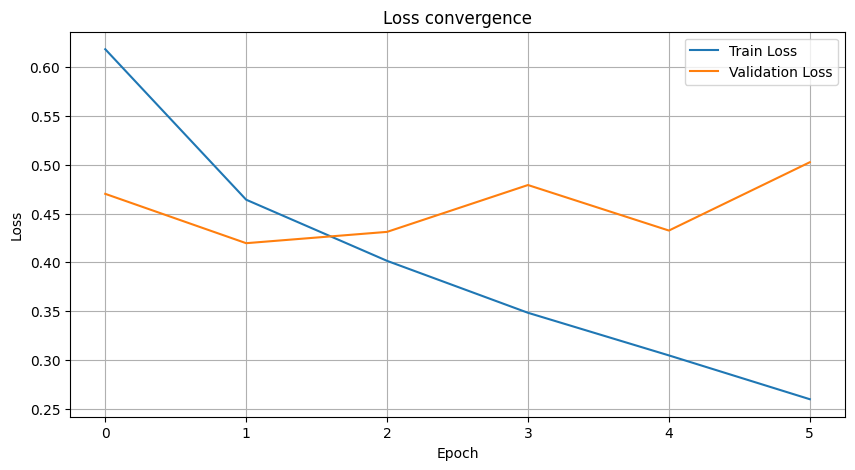

In [76]:
# BCELoss + RNN
set_seed(21)
vrnn_model = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyVanillaRNN)

criterion = nn.BCELoss(reduction='mean')
optimizer = torch.optim.Adam(vrnn_model.parameters(),  lr=config.lr, weight_decay=config.weight_decay)

train_losses, val_losses = train_val_loop(vrnn_model, train_loader, val_loader, criterion, optimizer, num_epochs=6, mode="gender")

In [77]:
v_rnn_list = new_names(vrnn_model)
v_rnn_list

['ahrky',
 'mihrly',
 'elyrktdqqaajrcj',
 'arzrlycmauarzfw',
 'dihrfypaujrjwi',
 'rarrfdcveanfwfrhj',
 'emhrktdqqqqtlrxji']

In [78]:
vrnn_roc_auc = calc_roc_auc(vrnn_model, test_loader)

Test ROC AUC: 0.8892


Epoch 1/6 | Train Loss: 0.6699 | Val Loss: 0.4843
Epoch 2/6 | Train Loss: 0.4980 | Val Loss: 0.4291
Epoch 3/6 | Train Loss: 0.4453 | Val Loss: 0.4137
Epoch 4/6 | Train Loss: 0.4281 | Val Loss: 0.3948
Epoch 5/6 | Train Loss: 0.4128 | Val Loss: 0.4055
Epoch 6/6 | Train Loss: 0.3970 | Val Loss: 0.3942


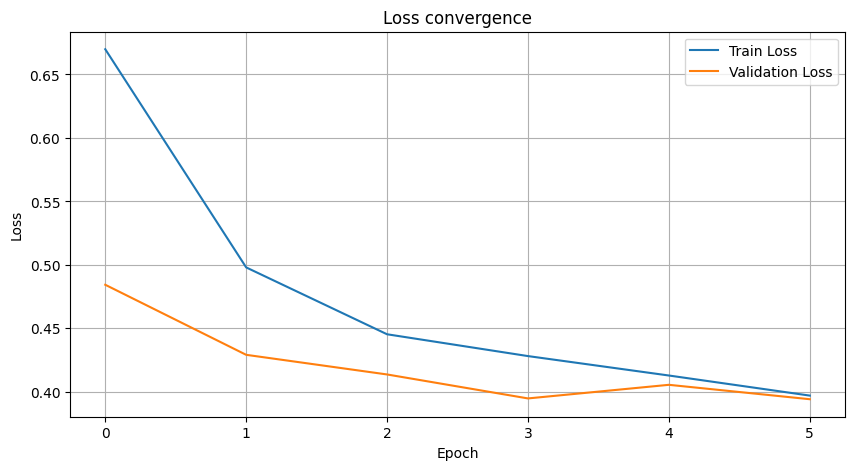

In [81]:
# BCELoss + GRU
set_seed(21)
model_GRU = NameGeneratorClassifier(config.vocab_size,
                                    config.embed_dim,
                                    config.hidden_size,
                                    config.dropout_prob,
                                    rnn_class=MyGRU)


criterion = nn.BCELoss(reduction='mean')

optimizer = torch.optim.Adam(model_GRU.parameters(), lr=config.lr, weight_decay=config.weight_decay)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=config.patience, factor=config.factor)

train_losses, val_losses = train_val_loop(model_GRU, train_loader, val_loader, criterion, optimizer, num_epochs=6, mode="gender", scheduler=scheduler)

In [82]:
gru_list = new_names(model_GRU)
gru_list

['ayyltcawamklrazy',
 'micrayeawleklwfxj',
 'elfraygyllekbebhy',
 'aryekecawamklrazy',
 'diirayeawleklwfxj',
 'rayyltccantltfzj',
 'emhqkygawleklwffy']

In [83]:
gru_roc_auc = calc_roc_auc(model_GRU, test_loader)

Test ROC AUC: 0.9009


Epoch 1/6 | Train Loss: 0.6816 | Val Loss: 0.5411
Epoch 2/6 | Train Loss: 0.5005 | Val Loss: 0.4433
Epoch 3/6 | Train Loss: 0.4667 | Val Loss: 0.4364
Epoch 4/6 | Train Loss: 0.4489 | Val Loss: 0.4352
Epoch 5/6 | Train Loss: 0.4293 | Val Loss: 0.4083
Epoch 6/6 | Train Loss: 0.4171 | Val Loss: 0.4200


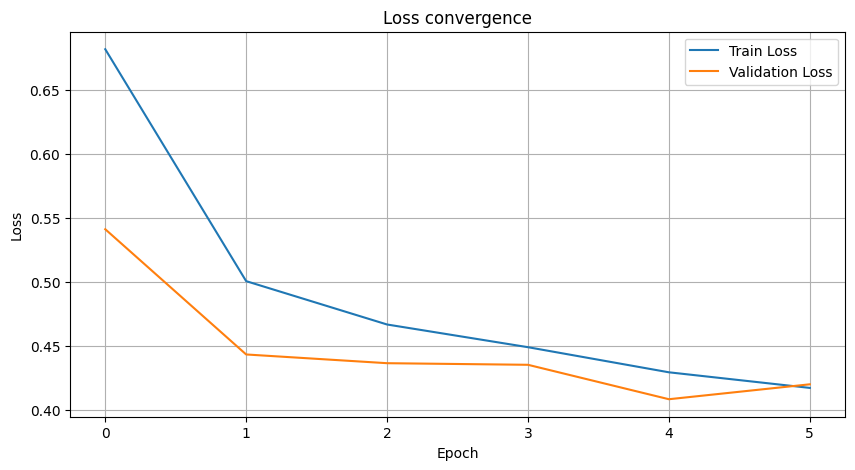

In [84]:
# BCELoss + LSTM
set_seed(21)
model_LSTM = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyLSTM)

criterion = nn.BCELoss(reduction='mean')
optimizer = torch.optim.Adam(model_LSTM.parameters(), lr=config.lr, weight_decay=config.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=config.patience, factor=config.factor)

train_losses, val_losses = train_val_loop(model_LSTM, train_loader, val_loader, criterion, optimizer, num_epochs=6, mode="gender", scheduler=scheduler)

In [85]:
lstm_list = new_names(model_LSTM)
lstm_list

['aygktc',
 'mihyfyggwuneayy',
 'elyyfycaeuiyohy',
 'aryyfycaeuiyohy',
 'dihyfyggwuneayy',
 'raygktc',
 'emxeldcaeuiyohy']

In [86]:
lstm_roc_auc = calc_roc_auc(model_LSTM, test_loader)

Test ROC AUC: 0.8999


Epoch 1/6 | Train Loss: 0.6473 | Val Loss: 0.5983
Epoch 2/6 | Train Loss: 0.4855 | Val Loss: 0.4400
Epoch 3/6 | Train Loss: 0.4192 | Val Loss: 0.4578
Epoch 4/6 | Train Loss: 0.3862 | Val Loss: 0.4408
Epoch 5/6 | Train Loss: 0.3457 | Val Loss: 0.4937
Epoch 6/6 | Train Loss: 0.3135 | Val Loss: 0.4465


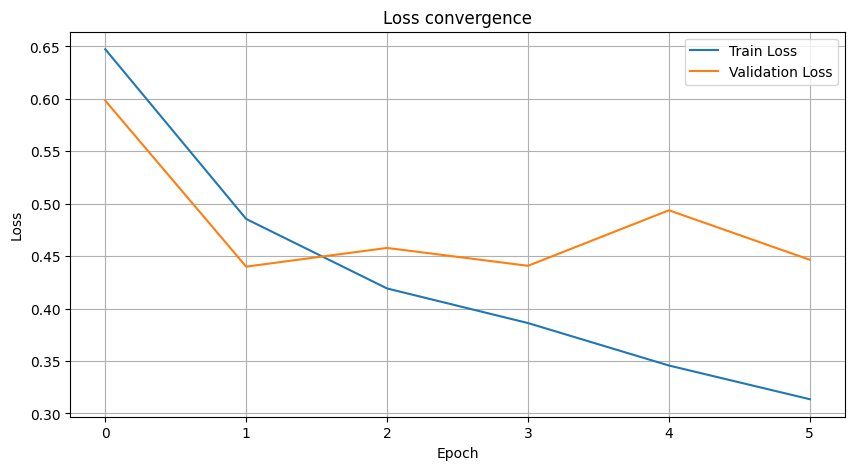

In [87]:
# NLLLoss + RNN
set_seed(21)
vrnn_model = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyVanillaRNN)

criterion = nn.NLLLoss(reduction='mean')
optimizer = torch.optim.Adam(vrnn_model.parameters(),  lr=config.lr, weight_decay=config.weight_decay)

train_losses, val_losses = train_val_loop(vrnn_model, train_loader, val_loader, criterion, optimizer, num_epochs=6, mode="gender")

In [88]:
v_rnn_list = new_names(vrnn_model)
v_rnn_list

['ahr eavmanfcjh',
 'mizrlycvmaujeasr',
 'eltrlycvlsn',
 'arzrlycvlsnjiehgr',
 'dizrlycveanakrnjy',
 'ratrlt',
 'emhgmtcvmaujezwi']

In [89]:
vrnn_roc_auc = calc_roc_auc(vrnn_model, test_loader)

Test ROC AUC: 0.8969


Epoch 1/6 | Train Loss: 0.6331 | Val Loss: 0.5200
Epoch 2/6 | Train Loss: 0.4806 | Val Loss: 0.4086
Epoch 3/6 | Train Loss: 0.4547 | Val Loss: 0.4534
Epoch 4/6 | Train Loss: 0.4280 | Val Loss: 0.4164
Epoch 5/6 | Train Loss: 0.4214 | Val Loss: 0.3968
Epoch 6/6 | Train Loss: 0.3880 | Val Loss: 0.3910


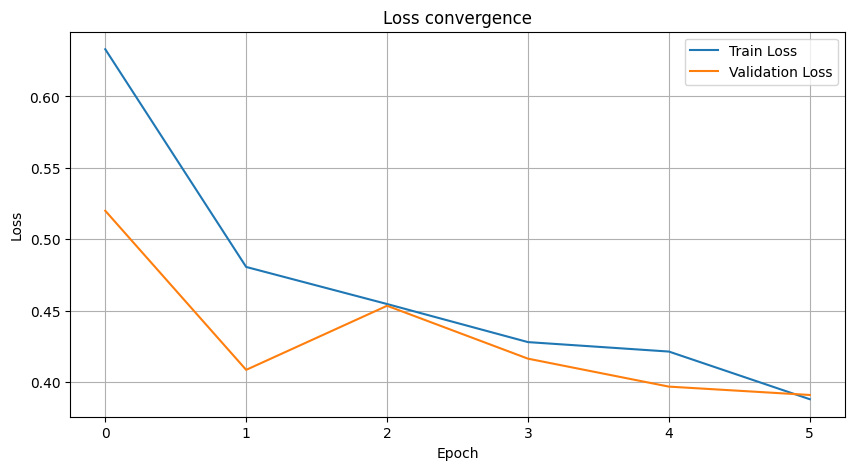

In [90]:
# NLLLoss + GRU
set_seed(21)
model_GRU = NameGeneratorClassifier(config.vocab_size,
                                    config.embed_dim,
                                    config.hidden_size,
                                    config.dropout_prob,
                                    rnn_class=MyGRU)


criterion = nn.NLLLoss(reduction='mean')

optimizer = torch.optim.Adam(model_GRU.parameters(), lr=config.lr, weight_decay=config.weight_decay)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=config.patience, factor=config.factor)

train_losses, val_losses = train_val_loop(model_GRU, train_loader, val_loader, criterion, optimizer, num_epochs=6, mode="gender", scheduler=scheduler)

In [91]:
gru_list = new_names(model_GRU)
gru_list

['ayyltcglfxtjlt',
 'micrayeammckjlra ',
 'eltrfyglsqklrazy',
 'aryekebwffxtjlt',
 'diyekecawamklrazy',
 'rayyltccabklwfxj',
 'emhr tcxfxtjlt']

In [92]:
gru_roc_auc = calc_roc_auc(model_GRU, test_loader)

Test ROC AUC: 0.9035


Epoch 1/6 | Train Loss: 0.6704 | Val Loss: 0.5257
Epoch 2/6 | Train Loss: 0.4985 | Val Loss: 0.4604
Epoch 3/6 | Train Loss: 0.4628 | Val Loss: 0.4305
Epoch 4/6 | Train Loss: 0.4490 | Val Loss: 0.4515
Epoch 5/6 | Train Loss: 0.4475 | Val Loss: 0.4058
Epoch 6/6 | Train Loss: 0.4268 | Val Loss: 0.3980


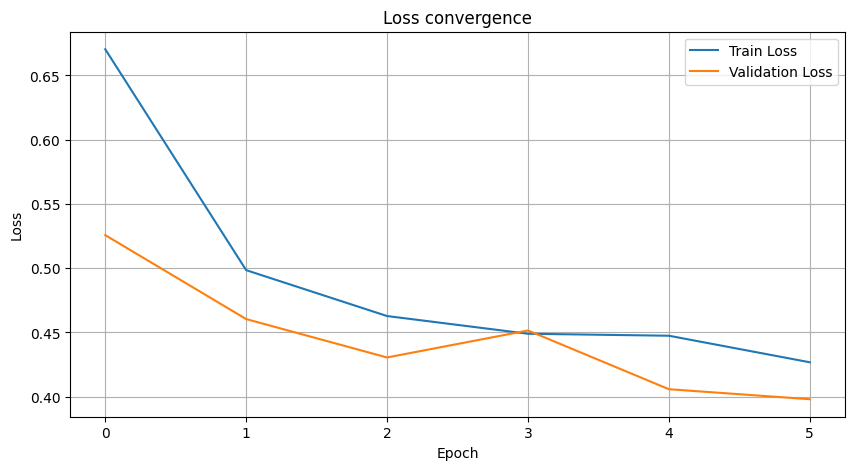

In [93]:
# NLLLoss + LSTM
set_seed(21)
model_LSTM = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyLSTM)

criterion = nn.NLLLoss(reduction='mean')
optimizer = torch.optim.Adam(model_LSTM.parameters(), lr=config.lr, weight_decay=config.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=config.patience, factor=config.factor)

train_losses, val_losses = train_val_loop(model_LSTM, train_loader, val_loader, criterion, optimizer, num_epochs=6, mode="gender", scheduler=scheduler)

In [94]:
lstm_list = new_names(model_LSTM)
lstm_list

['aygktctqamkiwhyy',
 'mihyfygvlljirspt',
 'eltrldcaeuioezb',
 'artrltcalamxiwhgw',
 'dihyfyggwuuiehyy',
 'raygktctqamkiwhyy',
 'emxeltcalamxldci']

In [95]:
lstm_roc_auc = calc_roc_auc(model_LSTM, test_loader)

Test ROC AUC: 0.8969


## Evaluation

- Plot loss convergence on training and valid data. - сверху

- Sample 10 names. Are they realistic? (Remember to put the model in eval mode.)
- продуцируют рандомный набор букв.

- Predict the gender of the names from the test data and compute the ROC AUC score.
- ROC-AUC выше (0.8-0.9), чем когда мы обучали модель предсказывать следующий токен.

# 9. Vanishing Gradient

#### a. Take a subset of the training data set where the length of the names is equal to their mode (mode=6)

<Axes: xlabel='Name', ylabel='Count'>

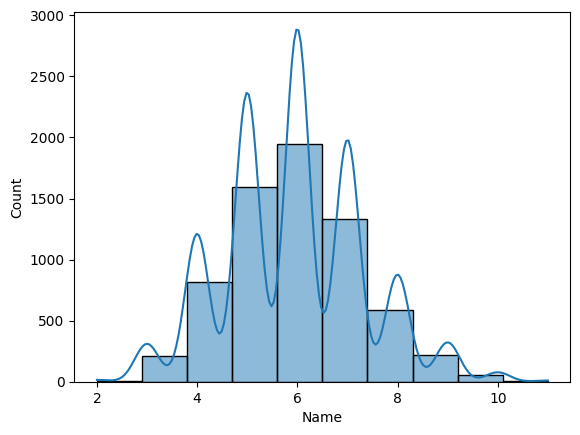

In [96]:
sns.histplot(data=name_data, x=name_data["Name"].str.len(), kde=True, bins=10)

In [97]:
new_name_data = name_data[["Name", "Gender", "Tokens"]]
new_name_data_filtered = new_name_data[new_name_data["Name"].str.len()==6]

In [98]:
new_name_data_filtered = new_name_data_filtered.copy()
new_name_data_filtered["Name_to_id"] = new_name_data_filtered["Tokens"].apply(lambda s: [alphabet_dict[ch] for ch in s])
new_name_data_filtered

,Name,Gender,Tokens,Name_to_id
3,george,0,"[<SOS>, g, e, o, r, g, e, <EOS>]","[27, 7, 5, 15, 18, 7, 5, 28]"
5,joseph,0,"[<SOS>, j, o, s, e, p, h, <EOS>]","[27, 10, 15, 19, 5, 16, 8, 28]"
6,thomas,0,"[<SOS>, t, h, o, m, a, s, <EOS>]","[27, 20, 8, 15, 13, 1, 19, 28]"
8,robert,0,"[<SOS>, r, o, b, e, r, t, <EOS>]","[27, 18, 15, 2, 5, 18, 20, 28]"
9,edward,0,"[<SOS>, e, d, w, a, r, d, <EOS>]","[27, 5, 4, 23, 1, 18, 4, 28]"
...,...,...,...,...
6774,karsyn,1,"[<SOS>, k, a, r, s, y, n, <EOS>]","[27, 11, 1, 18, 19, 25, 14, 28]"
6775,jamiya,1,"[<SOS>, j, a, m, i, y, a, <EOS>]","[27, 10, 1, 13, 9, 25, 1, 28]"
6776,laylah,1,"[<SOS>, l, a, y, l, a, h, <EOS>]","[27, 12, 1, 25, 12, 1, 8, 28]"
6778,kenley,1,"[<SOS>, k, e, n, l, e, y, <EOS>]","[27, 11, 5, 14, 12, 5, 25, 28]"


#### b. Implement the collection of gradients during model fitting for the embedding layer. The collected tensor should have the shape (n_epochs, max_name_length, n_tokens, embedding_size):

- in pytorch you can use register_backward_hook;
- in tensorflow you can use tf.GradientTape() or a custom callback.

In [99]:
# выход модели (batch_size, seq_len-1, vocab_size)
# выход эмбеддинга  emb = self.embedding(x) # (batch_size, seq_len, emb_dim)

In [100]:
from torch.nn.modules.module import register_module_backward_hook

In [101]:
def collect_gradients(model, num_epochs, loader, mode):
  max_len = 8
  vocab_size = 29
  embed_dim = model.embedding.embedding_dim

  device = config.device
  criterion = nn.CrossEntropyLoss(ignore_index=0, reduction='sum') if mode=="letter" else nn.BCELoss(reduction='sum')
  optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

  all_epoch_grads = []
  epoch_grads = []

  def hook_func(module, grad_input, grad_output):
    module_grads = grad_output[0].detach().clone()
    # (batch_size, seq_len, emb_dim)
    epoch_grads.append(module_grads)

  #hook_handle = model.embedding.register_backward_hook(hook_func)
  hook_handle = model.embedding.register_full_backward_hook(hook_func)

  model = model.to(device)
  model.train()
  for epoch in range(num_epochs):
    epoch_grads.clear()

    accum_grad = torch.zeros(max_len, vocab_size, embed_dim, device=device)
    counts =  torch.zeros(max_len, vocab_size, dtype=torch.long, device=device)

    for batch_seq, batch_gender in loader:
      batch_seq = batch_seq.to(device)
      batch_gender = batch_gender.to(device)
      optimizer.zero_grad()

      letter_logits, gender_logits = model(batch_seq)
      if mode=="letter":
        input = letter_logits[:, :-1, :].reshape(-1, letter_logits.size(-1))
        target = batch_seq[:, 1:].reshape(-1)
      else: # mode="gender"
        batch_gender = batch_gender.to(device)
        input = gender_logits # (batch_size,1)
        target = batch_gender # (batch_size,1)

      loss = criterion(input, target)
      loss.backward()
      # hook заполнил epoch_grads
      # grad (batch_size, seq_len, emb_dim)
      if epoch_grads:
        #print(epoch_grads)
        #print(len(epoch_grads))
        batch_grads = epoch_grads[-1] # (1, 8, 64)
        #print(epoch_grads[-1].shape)
        # копим для каждого примера в батче и токена
        for b in range(batch_seq.size(0)):
          seq_len = batch_seq.size(1)
          if (mode=="letter"):
            for pos in range(max_len-1):
              token_id = batch_seq[b, pos+1].item()
              if (token_id !=0):
                grad_vector = batch_grads[b, pos, :] # (embed_dim,)
                accum_grad[pos, token_id] += grad_vector
                counts[pos, token_id] += 1
          else: # gender
            for pos in range(max_len):
              token_id = batch_seq[b, pos].item()
              if (token_id != 0):
                grad_vector = batch_grads[b, pos, :]
                accum_grad[pos, token_id] += grad_vector
                counts[pos, token_id] += 1



      optimizer.step()

    mask = counts > 0
    epoch_grad_avg = torch.zeros_like(accum_grad)
    epoch_grad_avg[mask] = accum_grad[mask] / counts[mask].float().unsqueeze(-1)
    all_epoch_grads.append(epoch_grad_avg.cpu())

  hook_handle.remove()

  result = torch.stack(all_epoch_grads, dim=0)  # (n_epochs, max_len, vocab_size, embed_dim)
  return result

In [102]:
class OneLoader:
  def __init__(self, name_tensor, gender_tensor):
    self.name_tensor = name_tensor
    self.gender_tensor = gender_tensor

  def __iter__(self):
    yield self.name_tensor, self.gender_tensor

#### c. Debug the gradient collection with batch_size=1 and n_epochs=1:

-  Compute the norm of each vector along the last dimension. You will get a tensor with shape (1, max_name_length, n_tokens).
-  Compare which tokens have non-zero gradient norm with the tokens of the names (note that register_backward_hook will collect the gradient from the last token to the first).

In [103]:
X_new_train = np.array(new_name_data_filtered["Name_to_id"].tolist())
Y_new_train = np.array(new_name_data_filtered["Gender"].tolist())

name_tensor = NameDataset(X_new_train, Y_new_train)[0][0].unsqueeze(0)
gender_tensor = NameDataset(X_new_train, Y_new_train)[0][1].unsqueeze(0)

In [104]:
print(name_tensor)
print(gender_tensor)

tensor([[27,  7,  5, 15, 18,  7,  5, 28]])
tensor([[0.]])


In [105]:
set_seed(21)
vrnn_model = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyVanillaRNN)

In [106]:
loader = OneLoader(name_tensor, gender_tensor)
grads = collect_gradients(vrnn_model, num_epochs=1, loader=loader, mode="letter")

/tmp/ipykernel_375/1843172363.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


In [107]:
grads.shape

torch.Size([1, 8, 29, 128])

In [108]:
grad_norms = torch.norm(grads[0], dim=-1).unsqueeze(0) # fro
grad_norms.size() # (1, max_len, n_tokens)

torch.Size([1, 8, 29])

In [109]:
grad_norms = grad_norms.squeeze(0)
grad_norms.size() # (max_len, n_tokens)

torch.Size([8, 29])

In [110]:
grad_norms[0]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.3959, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000])

In [111]:
original_tokens = name_tensor.squeeze(0).tolist()
original_tokens

[27, 7, 5, 15, 18, 7, 5, 28]

In [112]:
threshold = 1e-6

for i in range(8):
    row = grad_norms[i]
    non_zero = torch.where(row > threshold)[0]
    if len(non_zero) > 0:
        token = non_zero[0].item()
        expected_pos = i + 1
        if expected_pos < len(original_tokens):
            expected_token = original_tokens[expected_pos]
            if token == expected_token:
                print(f"Позиция {i}: OK, токен {token} соответствует имени на позиции {expected_pos}")
            else:
                print(f"Позиция {i}: ОШИБКА, ожидали {expected_token}, получен {token}")
        else:
            print(f"Позиция {i}: паддинг (все нули), токен {token}")
    else:
        print(f"Позиция {i}: все нули")

Позиция 0: OK, токен 7 соответствует имени на позиции 1
Позиция 1: OK, токен 5 соответствует имени на позиции 2
Позиция 2: OK, токен 15 соответствует имени на позиции 3
Позиция 3: OK, токен 18 соответствует имени на позиции 4
Позиция 4: OK, токен 7 соответствует имени на позиции 5
Позиция 5: OK, токен 5 соответствует имени на позиции 6
Позиция 6: OK, токен 28 соответствует имени на позиции 7
Позиция 7: все нули


### d. Compute the Frobenius norm of the gradient matrix for each epoch and token position. The resulting tensor should have the form (n_epochs, max_name_length).

In [113]:
name_tensors = NameDataset(X_new_train, Y_new_train)

In [114]:
set_seed(21)
vrnn_model = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyVanillaRNN)

grad_loader = DataLoader(name_tensors, config.batch_size, shuffle=False)
vrnn_grads = collect_gradients(vrnn_model, num_epochs=10, loader=grad_loader, mode="letter")

/tmp/ipykernel_375/1843172363.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


In [115]:
vrnn_grads.size()

torch.Size([10, 8, 29, 128])

In [116]:
vrnn_grad_norms = torch.norm(vrnn_grads, dim=(-2, -1))
vrnn_grad_norms.size()

torch.Size([10, 8])

### e. Take the mean over the epochs.

In [117]:
vrnn_grad_norms_mean = torch.mean(vrnn_grad_norms, dim=0)
vrnn_grad_norms_mean

tensor([2.5815, 1.9779, 1.6746, 1.8313, 1.8234, 1.9022, 0.0127, 0.0000])

In [118]:
def mean_grad_norm(grads):
  grad_norms = torch.norm(grads, dim=(-2, -1)) # (num_epochs, max_len)
  grad_norms_mean = torch.mean(grad_norms, dim=0) # (max_len)
  torch.set_printoptions(precision=4)
  print(grad_norms_mean)
  #print(f"Max value: {grad_norms_mean.max().item():.6e}")
  return grad_norms_mean

### f. Train models for the gender classification task. Plot and compare the distribution of mean gradient norm over token position for RNN, GRU, and LSTM architectures.

- Для режима "gender" градиенты собираются по выходу эмбеддинга всем позициям имени (max_len) без игнорирования паддинга; для каждой позициии градиент соответствует вкладу токена, стоящего на этой позиции, в предсказание пола.
- Loss вычисляется один раз для всего имени (по последнему скрытому состоянию).

In [123]:
set_seed(21)
vrnn_model = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyVanillaRNN)

vrnn_grads = collect_gradients(vrnn_model, num_epochs=15, loader=grad_loader, mode="gender")

/tmp/ipykernel_375/1843172363.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


In [124]:
set_seed(21)
model_GRU = NameGeneratorClassifier(config.vocab_size,
                                    config.embed_dim,
                                    config.hidden_size,
                                    config.dropout_prob,
                                    rnn_class=MyGRU)
gru_grads = collect_gradients(model_GRU, num_epochs=15, loader=grad_loader, mode="gender")

/tmp/ipykernel_375/1843172363.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


In [125]:
set_seed(21)
model_LSTM = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyLSTM)
lstm_grads = collect_gradients(model_LSTM, num_epochs=15, loader=grad_loader, mode="gender")

/tmp/ipykernel_375/1843172363.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


In [126]:
vrnn_grads_mean = mean_grad_norm(vrnn_grads)
gru_grads_mean = mean_grad_norm(gru_grads)
lstm_grads_mean = mean_grad_norm(lstm_grads)

tensor([0.0097, 0.0522, 0.0752, 0.0604, 0.0653, 0.1093, 0.1744, 0.0161])
tensor([0.0008, 0.0169, 0.0471, 0.0384, 0.0887, 0.2104, 0.3019, 0.0062])
tensor([0.0006, 0.0121, 0.0337, 0.0282, 0.0524, 0.1571, 0.2584, 0.0054])


- Основное: так как вычисленный единожды лосс распространяется назад от последнего шага к первому, градиенты затухают по мере движения от последних позиций к первым (справа налево от 6й позиции к 0й).

- На концах - служебные токены (SOS, EOS), присутствуют во всех примерах, модель учится игнорировать их вклад. Кроме того, позиция 0 максимально удалена от выхода и получает самые маленькие градиенты.
- Позиции [1;6] –информативные буквы имени. Наблюдается рост градиентов от позиции 1 к позиции 6. Поскольку обратное распространение идёт от конца, позиция 6 (предпоследняя буква) находится ближе всего к выходу и получает самые большие градиенты. Позиция 1  дальше от конца, и градиенты к ней ослабевают (затухают), что объясняет меньшие значения.

- Vanilla RNN в теории должна сильнее страдать от затухания, (отношение  норм градиентов на позиции 6 к позиции 1), однако в случае короткихх последовательностей (имена) этот эффект, по-видимому, не проявляется.
- GRU и LSTM: гейты (забывания, обновления, выходной) позволяют модели избирательно сохранять или сбрасывать информацию. В результате градиенты могут течь через временные шаги с меньшими потерями, особенно на поздних шагах, где сосредоточена важная для пола информация (окончания имён).

### g. Repeat steps b-f when training the model for the next letter prediction task. What is the difference?

- Для режима "letter" градиенты собираются по выходу эмбеддинга по всем позициям имени, КРОМЕ ПОСЛЕДНЕЙ (max_len-1), паддинг игнорируется. Для каждой позциии градиент соответствует вкладу токена, стоящего на СЛЕДУЮЩЕЙ позиции (pos+1).
- Loss вычисляется ОТДЕЛЬНО для каждой буквы (на каждом шаге последовательности).

In [127]:
set_seed(21)
vrnn_model = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyVanillaRNN)

vrnn_grads = collect_gradients(vrnn_model, num_epochs=15, loader=grad_loader, mode="letter")

/tmp/ipykernel_375/1843172363.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


In [128]:
set_seed(21)
model_GRU = NameGeneratorClassifier(config.vocab_size,
                                    config.embed_dim,
                                    config.hidden_size,
                                    config.dropout_prob,
                                    rnn_class=MyGRU)
gru_grads = collect_gradients(model_GRU, num_epochs=15, loader=grad_loader, mode="letter")

/tmp/ipykernel_375/1843172363.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


In [129]:
set_seed(21)
model_LSTM = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyLSTM)
lstm_grads = collect_gradients(model_LSTM, num_epochs=15, loader=grad_loader, mode="letter")

/tmp/ipykernel_375/1843172363.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


In [130]:
vrnn_grads_mean = mean_grad_norm(vrnn_grads)
gru_grads_mean = mean_grad_norm(gru_grads)
lstm_grads_mean = mean_grad_norm(lstm_grads)

tensor([2.5450, 2.0387, 1.7474, 1.9067, 1.9141, 2.0287, 0.0092, 0.0000])
tensor([1.5992, 2.2414, 1.8205, 1.9583, 2.0029, 2.1746, 0.0344, 0.0000])
tensor([1.4350, 2.2524, 1.7545, 1.8905, 1.9201, 2.0900, 0.0363, 0.0000])


- Основное: вычисляемый для каждой позиции лосс распространяется назад от своей позциии, в результате все позиции получают обновления примерно одного порядка.

- Позиции 0–5: градиенты значительные (2.5-1). Это соответствует предсказаниям следующих токенов для реальных букв имени.

- Позиция 6: градиенты маленькие (0.005 - 0.01). Это предсказание следующего токена для позиции 6, которым является EOS или паддинг. Так как EOS предсказывается с высокой уверенностью, градиенты малы.

- Позиция 7: нули, так как для неё нет предсказания.

- Vanilla RNN показывает более высокие градиенты на ранних шагах, что может указывать на её бОльшую чувствительность к начальным токенам или менее эффективное использование контекста.

### h. Explain why we used the subset of the training data with fixed-length names in step a.

- Чтобы устранить влияние разной длины при интерпретации значений градиентов по позициям; сравнить архитектуры на одинаковых данных.

# 10. Multitask Learning

### a. Train the GRU or LSTM model with 2 loss functions at the same time: the first is the loss from predicting the next letter, the second is the loss from gender classification.

In [131]:
def train_multitask(model, train_loader, val_loader, num_epochs):
    train_losses_letter = []
    train_losses_gender = []
    val_losses_letter = []
    val_losses_gender = []
    device = config.device
    model.to(device)
    criterion_letter = nn.CrossEntropyLoss(reduction='mean')
    criterion_gender = nn.BCELoss(reduction='mean')
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=config.patience, factor=config.factor)

    for epoch in range(num_epochs):
        model.train()
        total_train_loss_letter = 0.0
        total_train_loss_gender = 0.0
        num_batches = 0
        for batch_seq, batch_gender in train_loader:
            batch_seq = batch_seq.to(device)
            batch_gender = batch_gender.to(device).float()
            if batch_gender.dim() == 1:
                batch_gender = batch_gender.unsqueeze(-1)

            optimizer.zero_grad()
            letter_logits, gender_prob = model(batch_seq)

            input_letter = letter_logits[:, :-1, :].reshape(-1, letter_logits.size(-1))
            target_letter = batch_seq[:, 1:].reshape(-1)
            loss_letter = criterion_letter(input_letter, target_letter)

            input_gender = gender_prob
            target_gender = batch_gender
            loss_gender = criterion_gender(input_gender, target_gender)

            loss = loss_letter + loss_gender
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss_letter += loss_letter.item()
            total_train_loss_gender += loss_gender.item()
            num_batches += 1

        avg_train_loss_letter = total_train_loss_letter / num_batches
        avg_train_loss_gender = total_train_loss_gender / num_batches
        train_losses_letter.append(avg_train_loss_letter)
        train_losses_gender.append(avg_train_loss_gender)

        model.eval()
        total_val_loss_letter = 0.0
        total_val_loss_gender = 0.0
        num_batches = 0
        with torch.no_grad():
            for batch_seq, batch_gender in val_loader:
                batch_seq = batch_seq.to(device)
                batch_gender = batch_gender.to(device).float()
                if batch_gender.dim() == 1:
                    batch_gender = batch_gender.unsqueeze(-1)

                letter_logits, gender_prob = model(batch_seq)

                input_letter = letter_logits[:, :-1, :].reshape(-1, letter_logits.size(-1))
                target_letter = batch_seq[:, 1:].reshape(-1)
                loss_letter = criterion_letter(input_letter, target_letter)

                input_gender = gender_prob
                target_gender = batch_gender
                loss_gender = criterion_gender(input_gender, target_gender)

                total_val_loss_letter += loss_letter.item()
                total_val_loss_gender += loss_gender.item()
                num_batches += 1

        avg_val_loss_letter = total_val_loss_letter / num_batches
        avg_val_loss_gender = total_val_loss_gender / num_batches
        val_losses_letter.append(avg_val_loss_letter)
        val_losses_gender.append(avg_val_loss_gender)

        scheduler.step(avg_val_loss_letter)

        print(f'Epoch {epoch+1}/{num_epochs} | Train L: {avg_train_loss_letter:.4f} G: {avg_train_loss_gender:.4f} | Val L: {avg_val_loss_letter:.4f} G: {avg_val_loss_gender:.4f}')

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses_letter, label='Train')
    plt.plot(val_losses_letter, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Letter Prediction Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(train_losses_gender, label='Train')
    plt.plot(val_losses_gender, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Gender Classification Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return train_losses_letter, train_losses_gender, val_losses_letter, val_losses_gender

tensor([-0.2386, -1.0934,  0.1558,  0.1750, -0.9526], grad_fn=<SliceBackward0>)
Epoch 1/16 | Train L: 1.6418 G: 0.6493 | Val L: 1.3820 G: 0.5391
Epoch 2/16 | Train L: 1.3757 G: 0.5348 | Val L: 1.3395 G: 0.4775
Epoch 3/16 | Train L: 1.3469 G: 0.4948 | Val L: 1.3175 G: 0.4672
Epoch 4/16 | Train L: 1.3262 G: 0.4787 | Val L: 1.3028 G: 0.4194
Epoch 5/16 | Train L: 1.3179 G: 0.4559 | Val L: 1.2953 G: 0.4510
Epoch 6/16 | Train L: 1.2995 G: 0.4514 | Val L: 1.2889 G: 0.4098
Epoch 7/16 | Train L: 1.2971 G: 0.4451 | Val L: 1.2860 G: 0.4469
Epoch 8/16 | Train L: 1.2894 G: 0.4553 | Val L: 1.2802 G: 0.4506
Epoch 9/16 | Train L: 1.2851 G: 0.4386 | Val L: 1.2778 G: 0.4103
Epoch 10/16 | Train L: 1.2814 G: 0.4275 | Val L: 1.2736 G: 0.3988
Epoch 11/16 | Train L: 1.2785 G: 0.4218 | Val L: 1.2713 G: 0.3946
Epoch 12/16 | Train L: 1.2762 G: 0.4268 | Val L: 1.2732 G: 0.4470
Epoch 13/16 | Train L: 1.2708 G: 0.4125 | Val L: 1.2679 G: 0.4208
Epoch 14/16 | Train L: 1.2688 G: 0.4158 | Val L: 1.2676 G: 0.3978
Epoch

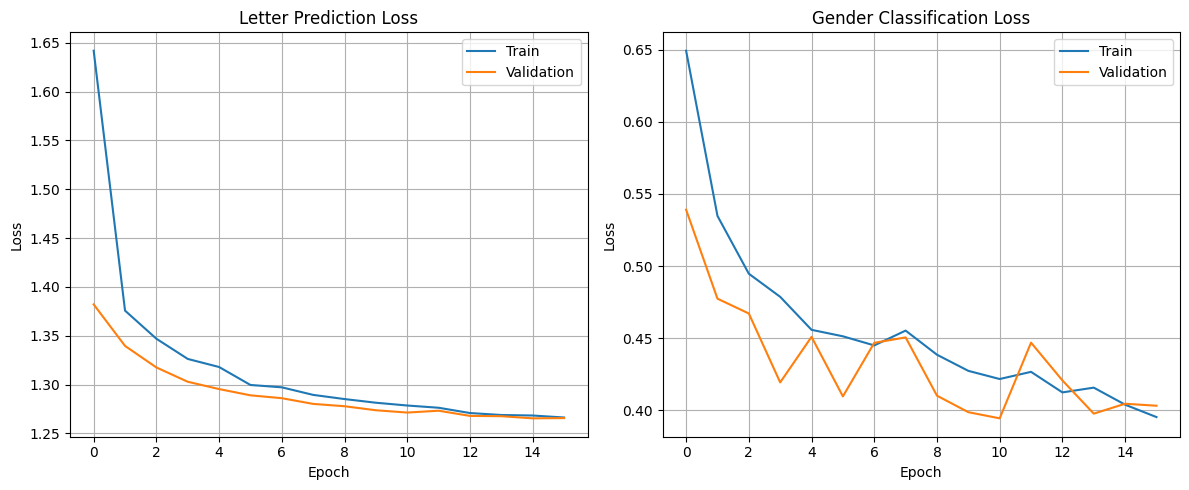

In [144]:
set_seed(21)
model_LSTM = NameGeneratorClassifier(config.vocab_size,
                                     embed_dim=32,
                                     hidden_size=256,
                                     dropout_prob=config.dropout_prob,
                                     rnn_class=MyLSTM)
print(model_LSTM.embedding.weight[0, :5])
train_losses_letter, train_losses_gender, val_losses_letter, val_losses_gender = train_multitask(model_LSTM, train_loader, val_loader, num_epochs=16)

## b. Evaluate

- Plot loss convergence for both loss functions on training and valid data. - см. выше
- Sample 10 names. Are they realistic? (Remember to put the model in eval mode.)
- Predict the gender of the names from the test data and calculate the ROC AUC score.

In [145]:
lstm_list = new_names(model_LSTM)
lstm_list

['arrie', 'mira', 'elarie', 'ariel', 'diana', 'rarile', 'emarlie']

In [146]:
lstm_roc_auc = calc_roc_auc(model_LSTM, test_loader)

Test ROC AUC: 0.9007


- ОБучение по двум функциям потерь научило модель и генерировать реалистичные имена, и достаточно уверенно предсказывать пол.

# 11. Visualizing embeddings

### a. Get the embeddings of each letter from the model with multitask loss.

In [147]:
embeddings = model_LSTM.embedding.weight
embeddings = embeddings.cpu().detach().numpy()
embeddings[:1] # (29, 64)

array([[-2.2530636e-01, -9.5852709e-01,  1.3477200e-01,  1.4193439e-01,
        -9.1088498e-01, -5.1428914e-01,  1.1046669e+00,  8.1963462e-01,
        -9.0864396e-01, -7.3542827e-01, -7.7901105e-04,  2.0852414e-01,
         8.2547313e-01, -5.0037533e-01, -2.3296468e-01,  8.2460469e-01,
         1.5266366e+00, -2.5578973e-01, -7.2052455e-01,  1.2908715e+00,
         1.6079226e+00,  1.0105410e+00,  2.1244012e-01, -6.4660358e-01,
         1.2341241e+00, -3.0731807e-02, -5.3700119e-01,  6.6789234e-01,
        -3.9591715e-01, -7.5370759e-02,  2.1184543e-01, -2.4745524e-01]],
      dtype=float32)

In [137]:
embeddings = model_LSTM.embedding.weight
embeddings = embeddings.cpu().detach().numpy()
embeddings[:1] # (29, 64)

array([[-0.22706789, -0.918759  ,  0.14139049,  0.15061541, -0.90731156,
        -0.5053382 ,  1.094211  ,  0.81923974, -0.97083306, -0.72914433,
        -0.00401953,  0.19974375,  0.8200556 , -0.49357337, -0.25767127,
         0.857778  ,  1.5170753 , -0.24238762, -0.7065173 ,  1.3108429 ,
         1.63691   ,  1.031287  ,  0.21704881, -0.64730215,  1.2339703 ,
        -0.02433245, -0.5338109 ,  0.6627287 , -0.39520198, -0.08291273,
         0.20517991, -0.247461  ]], dtype=float32)

### b. Use the TSNE model to compress vectors into 2 dimensions.

In [148]:
n_components_to_try = 2
tsne_model = TSNE(n_components=n_components_to_try,
                  random_state=21,
                  perplexity=28,
                  metric='euclidean',
                  init='random',
                  method='barnes_hut' #apprx with O(nlogn)
                  )

emb_tsne = tsne_model.fit_transform(embeddings)
emb_tsne.shape

(29, 2)

### c. Use PCA model to compress vectors into 2 dimensions.

In [149]:
pca_model = PCA(n_components=n_components_to_try, random_state=21, svd_solver='auto')
emb_pca = pca_model.fit_transform(embeddings)
emb_pca.shape

(29, 2)

In [150]:
results_for_visualization = []
results_for_visualization.append(('tSNE', emb_tsne))
results_for_visualization.append(('PCA', emb_pca))

### d. Split letters into vowels and consonants.

In [151]:
alphabet_dict
vowels = []
not_vowels = []

for key, value in alphabet_dict.items():
  if key in ["a","e","i","o","u"]:
    vowels.append(value)
  else:
    not_vowels.append(value)

print(vowels)
print(not_vowels)

[1, 5, 9, 15, 21]
[0, 2, 3, 4, 6, 7, 8, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28]


### e. Use scatterplot to visualize letter position in 2 dimensions for both compressions.

In [152]:
%matplotlib inline

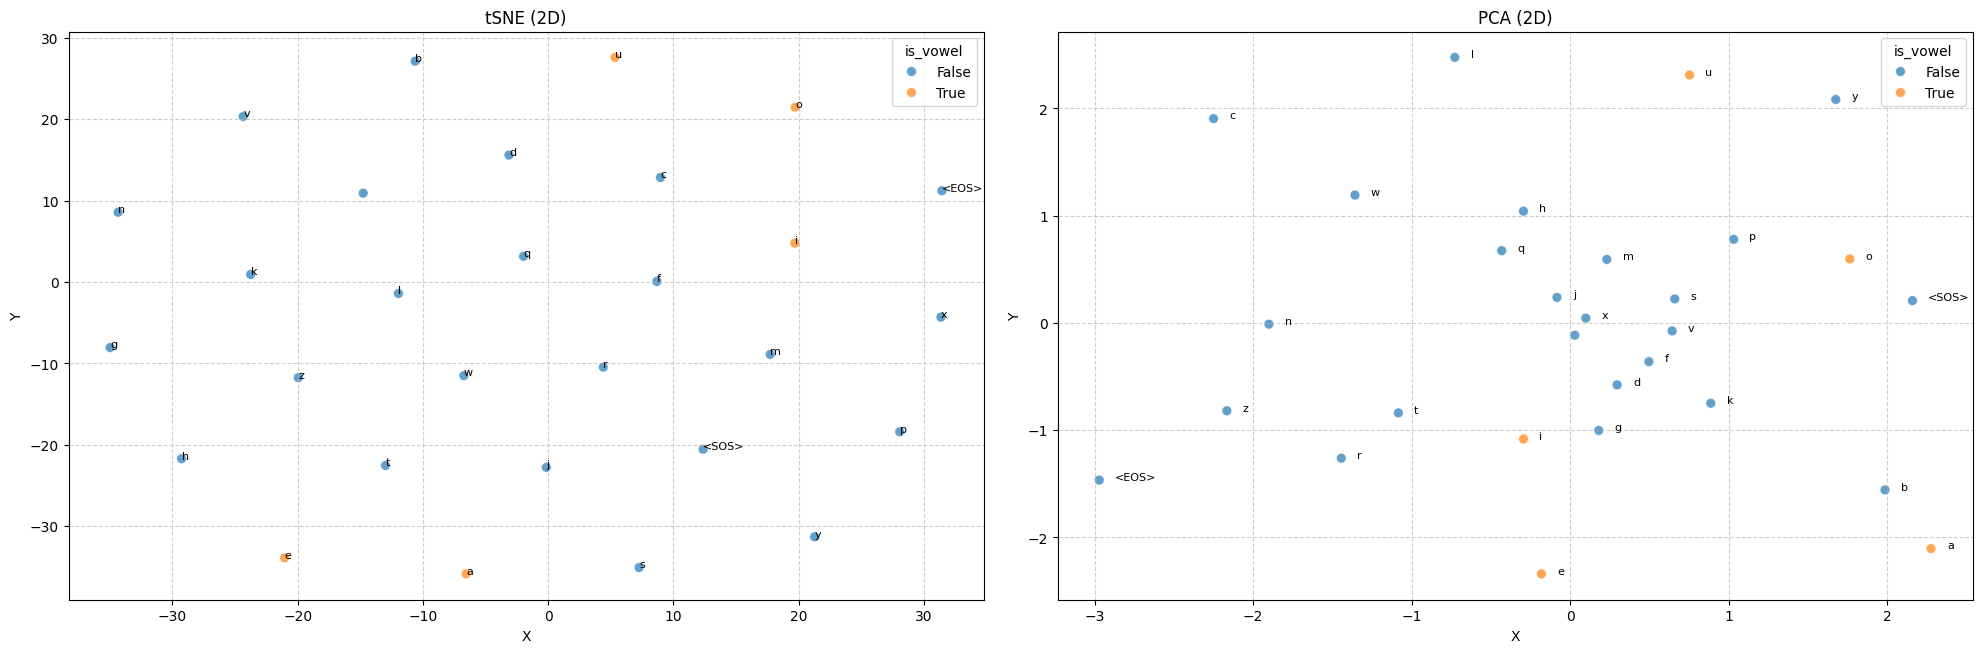

In [153]:
plt.figure(figsize=(20, 25))
for i, (method_name, data) in enumerate(results_for_visualization):
  ax = plt.subplot(4, 2, i+1)
  df_plot = pd.DataFrame({'X': data[:, 0], 'Y': data[:, 1]})
  df_plot['is_vowel'] = [i in vowels for i in range(len(data))]

  sns.scatterplot(x='X', y='Y', hue="is_vowel", data=df_plot,
                  palette=sns.color_palette('tab10', n_colors=2),
                  legend='full', alpha=0.7, ax=ax, s=50)

  ax.set_title(f'{method_name} (2D)')
  ax.set_xlabel('X')
  ax.set_ylabel('Y')
  ax.grid(True, linestyle='--', alpha=0.6)

  id_to_char = {v: k for k, v in alphabet_dict.items()}
  for i, (x, y) in enumerate(data):
    if method_name=="tSNE":
      ax.text(x+0.0005, y, id_to_char[i], fontsize=8)
    else: # PCA
      ax.text(x+0.1, y, id_to_char[i], fontsize=8)

plt.tight_layout()
plt.show()


### f. What can you infer from the plots?
- В случае tSNE при некотором подборе параметров видна частичная кластеризация гласных (o, i, u); гласные a,e при этом кластеризуются отдельно (возможно, потому что они часто в именах соседствуют с другими гласными - aisha, mirrie)
- В случае PCA гласные не кластеризуются отдельно от согласных.
- В целом, из-за невоспроизводимости результатов при разных параметрах и даже при одинаковых параметрах, но разных запусках (минимальные отличия по причине параллельных вычислений дают минимальные отличия в эмбеддингах > сильно отл-ся рез-ты для tSNE, PCA) можно сказать, что фонетические особенности наша обученная модель не улавливает.

# 12. Bonus Part

### Try to achieve an even better gender classification performance on the test dataset — ROC AUC 0.92+.

1) попробовать оптимизацию optuna по максимизации roc_auc - тут лучший результат для версий моделей выше при мультитаскинг-обучении - 0.9 - 0.91

2) bidirectional rnn - тут тоже 0.9

In [241]:
checkpoint = torch.load("best_model_nnGRU.pth")
best_params = checkpoint["hyperparameters"]

best_nnGRU_model = NameGeneratorClassifier(
    vocab_size=config.vocab_size,
    embed_dim=best_params['embed_dim'],
    hidden_size=best_params['hidden_size'],
    dropout_prob=best_params['dropout_prob'],
    rnn_class=nn.GRU,
    batch_first=True
).to(config.device)

best_nnGRU_model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [242]:
best_nnGRU_model_roc_auc = calc_roc_auc(best_nnGRU_model , test_loader)

Test ROC AUC: 0.9117


### Propose the method to get the embedding of each name. Collect, compress, and plot them using the split by gender

Epoch 1/10 | Train L: 1.5794 G: 0.6873 | Val L: 1.3367 G: 0.6236
Epoch 2/10 | Train L: 1.3295 G: 0.5357 | Val L: 1.2945 G: 0.4509
Epoch 3/10 | Train L: 1.2996 G: 0.4665 | Val L: 1.2792 G: 0.4447
Epoch 4/10 | Train L: 1.2808 G: 0.4654 | Val L: 1.2645 G: 0.4712
Epoch 5/10 | Train L: 1.2700 G: 0.4269 | Val L: 1.2613 G: 0.4525
Epoch 6/10 | Train L: 1.2592 G: 0.4351 | Val L: 1.2553 G: 0.4773
Epoch 7/10 | Train L: 1.2522 G: 0.4223 | Val L: 1.2468 G: 0.4185
Epoch 8/10 | Train L: 1.2438 G: 0.4003 | Val L: 1.2450 G: 0.3877
Epoch 9/10 | Train L: 1.2395 G: 0.3818 | Val L: 1.2407 G: 0.4132
Epoch 10/10 | Train L: 1.2315 G: 0.3711 | Val L: 1.2360 G: 0.3912


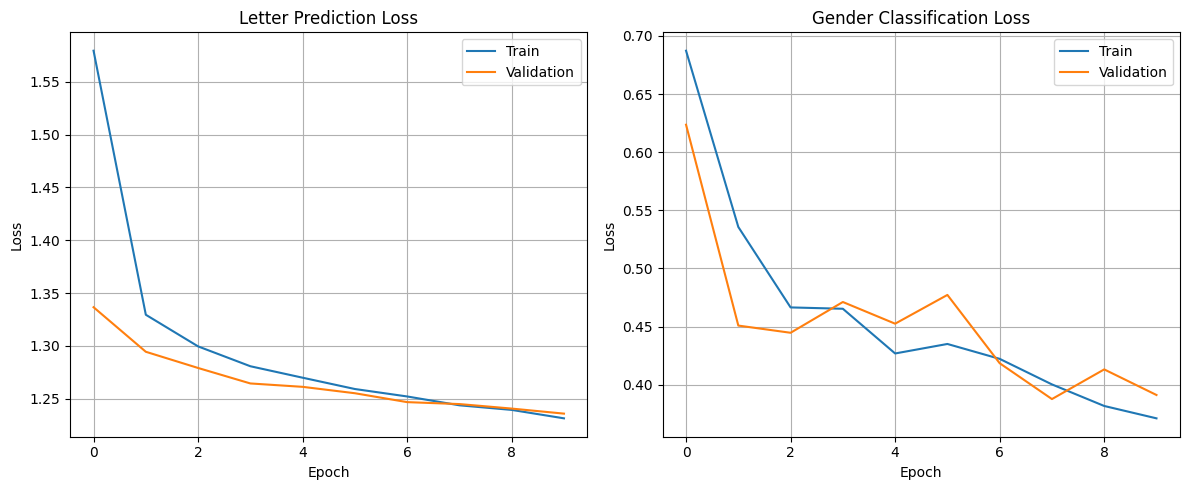

In [213]:
set_seed(21)
model_LSTM = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=MyLSTM)
train_losses_letter, train_losses_gender, val_losses_letter, val_losses_gender = train_multitask(model_LSTM, train_loader, val_loader, num_epochs=10)

In [214]:
def collect_name_emb_lstm(model, val_loader):
  model.eval()
  device = config.device
  name_embs = []
  genders = []
  with torch.no_grad():
    for batch_seq, batch_gender in val_loader:
      batch_seq = batch_seq.to(device)
      emb = model.embedding(batch_seq)
      _, last_hidden = model.rnn(emb, None)
      # LSTM (batch, hidden)
      name_embs.append(last_hidden.cpu().numpy())
      gender_np = batch_gender.cpu().numpy().flatten() # (batch,)
      genders.append(gender_np)

  name_embs = np.concatenate(name_embs, axis=0)  # (batch_size, hidden_size)  > (num_names, hidden_size)
  genders = np.concatenate(genders, axis=0)   # (num_names,)
  return name_embs, genders

In [215]:
name_ebs, genders = collect_name_emb_lstm(model_LSTM, val_loader)

In [216]:
n_components_to_try = 2
tsne_model = TSNE(n_components=n_components_to_try,
                  random_state=21,
                  perplexity=28,
                  metric='euclidean',
                  init='pca',
                  method='barnes_hut' #apprx with O(nlogn)
                  )
emb_tsne = tsne_model.fit_transform(name_ebs)
emb_tsne.shape

(2712, 2)

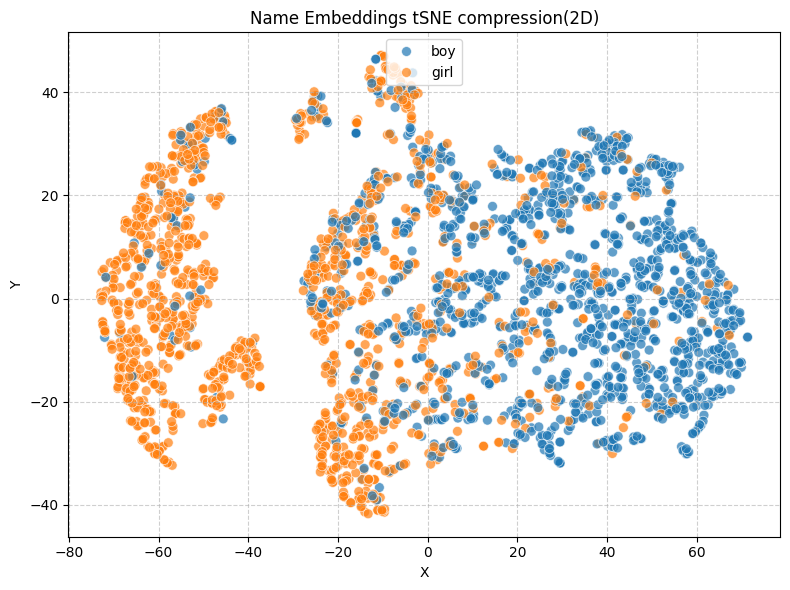

In [217]:
fig, ax = plt.subplots(figsize=(8, 6))

df_plot = pd.DataFrame({'X': emb_tsne[:, 0], 'Y': emb_tsne[:, 1]})
genders_dict = {0: "boy", 1: "girl"}
df_plot['gender'] = pd.Series(genders).map(genders_dict).values

sns.scatterplot(x='X', y='Y', hue="gender", data=df_plot,
                  palette=sns.color_palette('tab10', n_colors=2),
                  legend='full', alpha=0.7, ax=ax, s=50)

ax.set_title(f'Name Embeddings tSNE compression(2D)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, linestyle='--', alpha=0.6)

plt.legend(loc="upper center")

plt.tight_layout()
plt.show()

### Train gradient boosting trees for the gender classification task. Which features will you use? Evaluate and compare performance on a test dataset.

In [185]:
name_data

,Name,Gender,Tokens,Padded_tokens,Name_to_id
0,william,0,"[<SOS>, w, i, l, l, i, a, m, <EOS>]","[<SOS>, w, i, l, l, i, a, m, <EOS>, , , , ]","[27, 23, 9, 12, 12, 9, 1, 13, 28, 0, 0, 0, 0]"
1,james,0,"[<SOS>, j, a, m, e, s, <EOS>]","[<SOS>, j, a, m, e, s, <EOS>, , , , , , ]","[27, 10, 1, 13, 5, 19, 28, 0, 0, 0, 0, 0, 0]"
2,charles,0,"[<SOS>, c, h, a, r, l, e, s, <EOS>]","[<SOS>, c, h, a, r, l, e, s, <EOS>, , , , ]","[27, 3, 8, 1, 18, 12, 5, 19, 28, 0, 0, 0, 0]"
3,george,0,"[<SOS>, g, e, o, r, g, e, <EOS>]","[<SOS>, g, e, o, r, g, e, <EOS>, , , , , ]","[27, 7, 5, 15, 18, 7, 5, 28, 0, 0, 0, 0, 0]"
4,frank,0,"[<SOS>, f, r, a, n, k, <EOS>]","[<SOS>, f, r, a, n, k, <EOS>, , , , , , ]","[27, 6, 18, 1, 14, 11, 28, 0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...
6776,laylah,1,"[<SOS>, l, a, y, l, a, h, <EOS>]","[<SOS>, l, a, y, l, a, h, <EOS>, , , , , ]","[27, 12, 1, 25, 12, 1, 8, 28, 0, 0, 0, 0, 0]"
6777,carleigh,1,"[<SOS>, c, a, r, l, e, i, g, h, <EOS>]","[<SOS>, c, a, r, l, e, i, g, h, <EOS>, , , ]","[27, 3, 1, 18, 12, 5, 9, 7, 8, 28, 0, 0, 0]"
6778,kenley,1,"[<SOS>, k, e, n, l, e, y, <EOS>]","[<SOS>, k, e, n, l, e, y, <EOS>, , , , , ]","[27, 11, 5, 14, 12, 5, 25, 28, 0, 0, 0, 0, 0]"
6779,sloane,1,"[<SOS>, s, l, o, a, n, e, <EOS>]","[<SOS>, s, l, o, a, n, e, <EOS>, , , , , ]","[27, 19, 12, 15, 1, 14, 5, 28, 0, 0, 0, 0, 0]"


In [186]:
bt_train_val, bt_test_data = train_test_split(name_data[["Name","Name_to_id", "Gender"]],
                                   test_size=0.2,
                                   random_state=21,
                                   stratify=name_data["Gender"])

bt_train_data, bt_valid_data = train_test_split(bt_train_val,
                                   test_size=0.5,
                                   random_state=21,
                                   stratify=train_val["Gender"])

In [187]:
bt_train_data

,Name,Name_to_id,Gender
2327,lindell,"[27, 12, 9, 14, 4, 5, 12, 12, 28, 0, 0, 0, 0]",0
234,chris,"[27, 3, 8, 18, 9, 19, 28, 0, 0, 0, 0, 0, 0]",0
3701,lucia,"[27, 12, 21, 3, 9, 1, 28, 0, 0, 0, 0, 0, 0]",1
4404,mariam,"[27, 13, 1, 18, 9, 1, 13, 28, 0, 0, 0, 0, 0]",1
1703,teddy,"[27, 20, 5, 4, 4, 25, 28, 0, 0, 0, 0, 0, 0]",0
...,...,...,...
5053,dorla,"[27, 4, 15, 18, 12, 1, 28, 0, 0, 0, 0, 0, 0]",1
5258,jerrilyn,"[27, 10, 5, 18, 18, 9, 12, 25, 14, 28, 0, 0, 0]",1
3976,evalena,"[27, 5, 22, 1, 12, 5, 14, 1, 28, 0, 0, 0, 0]",1
1556,irl,"[27, 9, 18, 12, 28, 0, 0, 0, 0, 0, 0, 0, 0]",0


In [188]:
def prepare_embs(model, loader):
  name_embs, genders = collect_name_emb_lstm(model, loader)
  return name_embs, genders

In [189]:
train_embs, train_genders = collect_name_emb_lstm(model_LSTM, train_loader) # (n, 256)
val_embs, val_genders   = collect_name_emb_lstm(model_LSTM, val_loader)
test_embs, test_genders  = collect_name_emb_lstm(model_LSTM, test_loader)

pca = PCA(n_components=25, random_state=21, svd_solver='auto')
train_embs_pca = pca.fit_transform(train_embs)
val_embs_pca   = pca.transform(val_embs)
test_embs_pca  = pca.transform(test_embs)

In [190]:
def extract_feats(name_data):
  names = name_data["Name"].tolist()
  data = []
  for name in names:
    data.append({
        'length': len(name),
        'first_letter': name[0] if name else '',
        'last_letter': name[-1] if name else '',
        'last_two': name[-2:] if len(name) >= 2 else name,
        'vowel_count': sum(1 for c in name if c in 'aeiou'),
        'consonant_count': sum(1 for c in name if c.isalpha() and c not in 'aeiou')
    })
  df = pd.DataFrame(data)
  return df

In [191]:
train_feat = extract_feats(bt_train_data)
val_feat = extract_feats(bt_valid_data)
test_feat = extract_feats(bt_test_data)

In [192]:
from sklearn.feature_extraction.text import CountVectorizer

In [193]:
char_vectorizer = CountVectorizer(
    analyzer='char',
    ngram_range=(2, 4),
    max_features=200,
    lowercase=True
)

In [194]:
train_names = bt_train_data["Name"].tolist()
train_ngrams = char_vectorizer.fit_transform(train_names)
print(char_vectorizer.get_feature_names_out()[:20])

['ab' 'ac' 'ad' 'ae' 'ah' 'ai' 'al' 'ale' 'ali' 'am' 'an' 'ana' 'and'
 'ani' 'ann' 'anna' 'ar' 'ard' 'ari' 'arl']


In [195]:
val_names = bt_valid_data["Name"].tolist()
test_names = bt_test_data["Name"].tolist()

val_ngrams = char_vectorizer.transform(val_names)
test_ngrams = char_vectorizer.transform(test_names)

In [196]:
train_ngrams_dense = train_ngrams.toarray()
val_ngrams_dense = val_ngrams.toarray()
test_ngrams_dense  = test_ngrams.toarray()

In [197]:
num_feat_names = [f'emb_{i}' for i in range(train_embs_pca.shape[1])] + \
                 [f'ngram_{i}' for i in range(train_ngrams_dense.shape[1])]
X_train_num = pd.DataFrame(
    np.hstack([train_embs_pca, train_ngrams_dense]),
    columns=num_feat_names
)
X_val_num = pd.DataFrame(
    np.hstack([val_embs_pca, val_ngrams_dense]),
    columns=num_feat_names
)
X_test_num = pd.DataFrame(
    np.hstack([test_embs_pca, test_ngrams_dense]),
    columns=num_feat_names
)

In [198]:
cat_columns = ['first_letter', 'last_letter', 'last_two', 'length', 'vowel_count', 'consonant_count']
X_train = pd.concat([X_train_num, train_feat[cat_columns]], axis=1)
X_val = pd.concat([X_val_num,   val_feat[cat_columns]],   axis=1)
X_test  = pd.concat([X_test_num,  test_feat[cat_columns]],  axis=1)

In [199]:
num_features = len(num_feat_names)
cat_features = list(range(num_features, num_features + len(cat_columns)))

In [200]:
!pip install -q catboost

In [201]:
# Catboost
from catboost import CatBoostClassifier, Pool

train_pool = Pool(X_train, label=bt_train_data["Gender"].values, cat_features=cat_features)
val_pool   = Pool(X_val,   label=bt_valid_data["Gender"].values, cat_features=cat_features)
test_pool = Pool(X_test, cat_features=cat_features)

In [202]:
cb = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    eval_metric='AUC',
    random_seed=21,
    early_stopping_rounds=50,
    verbose=100,
    task_type='CPU' #пчмт на гпу падает рантайм без предупреждений
)
cb.fit(train_pool, eval_set=val_pool)

0:	test: 0.8299717	best: 0.8299717 (0)	total: 11.9ms	remaining: 11.8s
100:	test: 0.8917365	best: 0.8921580 (91)	total: 1.19s	remaining: 10.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8935619437
bestIteration = 132

Shrink model to first 133 iterations.


CatBoostClassifier(early_stopping_rounds=50, eval_metric='AUC', iterations=1000, learning_rate=0.1, random_seed=21, task_type='CPU', verbose=100)

In [203]:
preds = cb.predict_proba(test_pool)[:, 1]
auc = roc_auc_score(bt_test_data["Gender"].values, preds)
print(f"Test AUC: {auc:.4f}")

Test AUC: 0.9005


- Получилось сопоставимое значение roc-auc (0.9) для задачи бинарной классификации пола, но с подготовкой признаков пришлось поработать. Были использованы как признаки:
1) эмбеддинги имен, полученные как последнее скрытое состояние обученной модели и сжатые с 256 до 25 компонент методом PCA;  - 25
2) признаки длины имени, кол-ва гласных и согласных, последние и первые буквы имен; - 6
3) топ-200 n-грамм (наиболее часто встр-ся сочетаний букв), подсчитанных CountVectorizer-ом. - 200

### Train torch/tensorflow/keras/etc built-in RNN, LSTM, GRU models and compare their performance with your models.

Epoch 1/16 | Train L: 1.5703 G: 0.7236 | Val L: 1.3155 G: 0.6959
Epoch 2/16 | Train L: 1.3181 G: 0.7057 | Val L: 1.2885 G: 0.6920
Epoch 3/16 | Train L: 1.2954 G: 0.7011 | Val L: 1.3057 G: 0.7106
Epoch 4/16 | Train L: 1.2919 G: 0.6354 | Val L: 1.2738 G: 0.5835
Epoch 5/16 | Train L: 1.2763 G: 0.5560 | Val L: 1.2769 G: 0.4737
Epoch 6/16 | Train L: 1.2772 G: 0.5418 | Val L: 1.2683 G: 0.4890
Epoch 7/16 | Train L: 1.2682 G: 0.4809 | Val L: 1.2710 G: 0.4511
Epoch 8/16 | Train L: 1.2637 G: 0.4395 | Val L: 1.2668 G: 0.4240
Epoch 9/16 | Train L: 1.2625 G: 0.4642 | Val L: 1.2661 G: 0.4419
Epoch 10/16 | Train L: 1.2576 G: 0.4519 | Val L: 1.2614 G: 0.4330
Epoch 11/16 | Train L: 1.2542 G: 0.4614 | Val L: 1.2597 G: 0.4523
Epoch 12/16 | Train L: 1.2587 G: 0.4272 | Val L: 1.2570 G: 0.4491
Epoch 13/16 | Train L: 1.2495 G: 0.4142 | Val L: 1.2595 G: 0.4378
Epoch 14/16 | Train L: 1.2496 G: 0.4078 | Val L: 1.2592 G: 0.4292
Epoch 15/16 | Train L: 1.2494 G: 0.3954 | Val L: 1.2544 G: 0.5307
Epoch 16/16 | Train

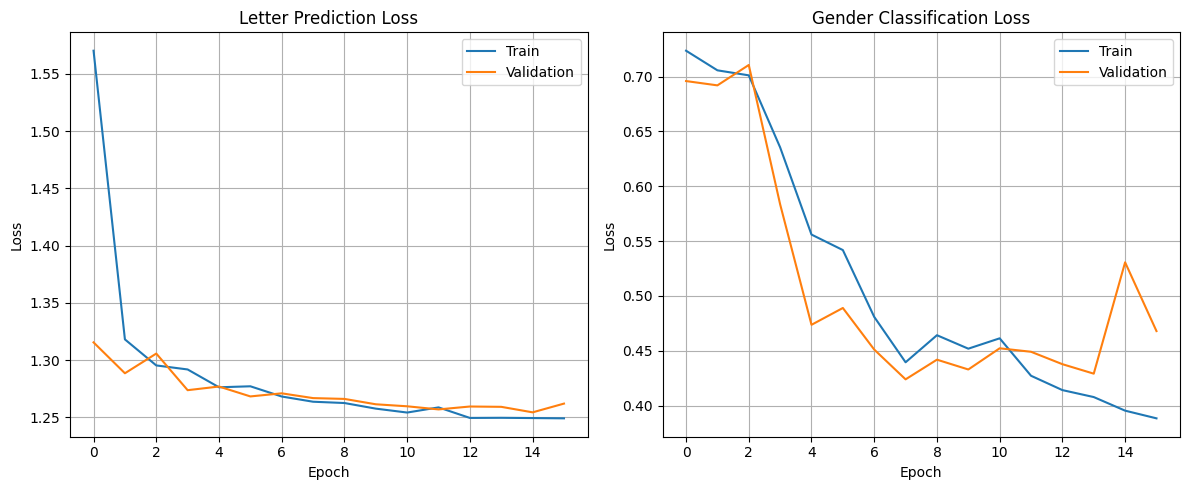

In [218]:
# vanilla RNN
set_seed(21)
model_vrnn = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=nn.RNN,
                                     batch_first=True)
train_losses_letter, train_losses_gender, val_losses_letter, val_losses_gender = train_multitask(model_vrnn, train_loader, val_loader, num_epochs=16)

In [219]:
vrnn_list = new_names(model_vrnn)
vrnn_list

['arrie', 'mirrie', 'elin', 'arisa', 'dian', 'rayn', 'emari']

In [220]:
vrnn_roc_auc = calc_roc_auc(model_vrnn, test_loader)

Test ROC AUC: 0.8899


Epoch 1/10 | Train L: 1.5575 G: 0.6662 | Val L: 1.3461 G: 0.5013
Epoch 2/10 | Train L: 1.3402 G: 0.5032 | Val L: 1.3057 G: 0.4852
Epoch 3/10 | Train L: 1.3076 G: 0.4720 | Val L: 1.2795 G: 0.4143
Epoch 4/10 | Train L: 1.2817 G: 0.4527 | Val L: 1.2682 G: 0.4162
Epoch 5/10 | Train L: 1.2657 G: 0.4290 | Val L: 1.2586 G: 0.4100
Epoch 6/10 | Train L: 1.2547 G: 0.4069 | Val L: 1.2516 G: 0.4067
Epoch 7/10 | Train L: 1.2464 G: 0.3972 | Val L: 1.2429 G: 0.4021
Epoch 8/10 | Train L: 1.2379 G: 0.3793 | Val L: 1.2389 G: 0.4035
Epoch 9/10 | Train L: 1.2320 G: 0.3719 | Val L: 1.2363 G: 0.4188
Epoch 10/10 | Train L: 1.2286 G: 0.3593 | Val L: 1.2336 G: 0.4210


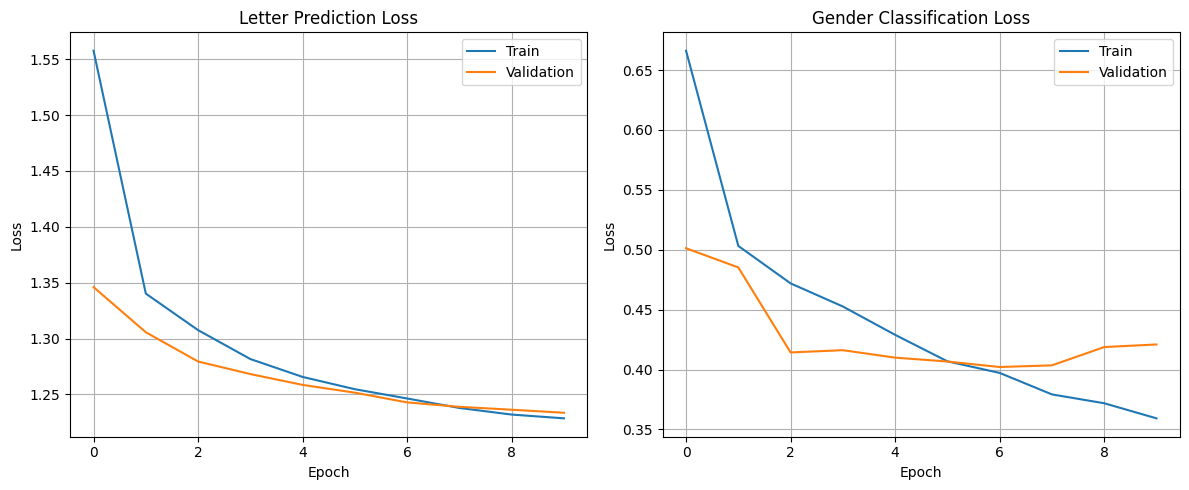

In [221]:
# GRU
set_seed(21)
model_gru = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=nn.GRU,
                                     batch_first=True)
train_losses_letter, train_losses_gender, val_losses_letter, val_losses_gender = train_multitask(model_gru, train_loader, val_loader, num_epochs=10)

In [222]:
gru_list = new_names(model_gru)
gru_list

['arrie', 'mirrie', 'elisa', 'arrile', 'dirra', 'rayla', 'emarle']

In [223]:
gru_roc_auc = calc_roc_auc(model_gru, test_loader)

Test ROC AUC: 0.9041


Epoch 1/10 | Train L: 1.5486 G: 0.7308 | Val L: 1.3375 G: 0.6845
Epoch 2/10 | Train L: 1.3306 G: 0.5983 | Val L: 1.2999 G: 0.4992
Epoch 3/10 | Train L: 1.3043 G: 0.5139 | Val L: 1.2829 G: 0.4495
Epoch 4/10 | Train L: 1.2886 G: 0.4807 | Val L: 1.2753 G: 0.4294
Epoch 5/10 | Train L: 1.2787 G: 0.4722 | Val L: 1.2624 G: 0.4335
Epoch 6/10 | Train L: 1.2648 G: 0.4601 | Val L: 1.2605 G: 0.4189
Epoch 7/10 | Train L: 1.2599 G: 0.4395 | Val L: 1.2527 G: 0.4136
Epoch 8/10 | Train L: 1.2472 G: 0.4345 | Val L: 1.2501 G: 0.4064
Epoch 9/10 | Train L: 1.2422 G: 0.4107 | Val L: 1.2485 G: 0.3984
Epoch 10/10 | Train L: 1.2349 G: 0.4095 | Val L: 1.2405 G: 0.4038


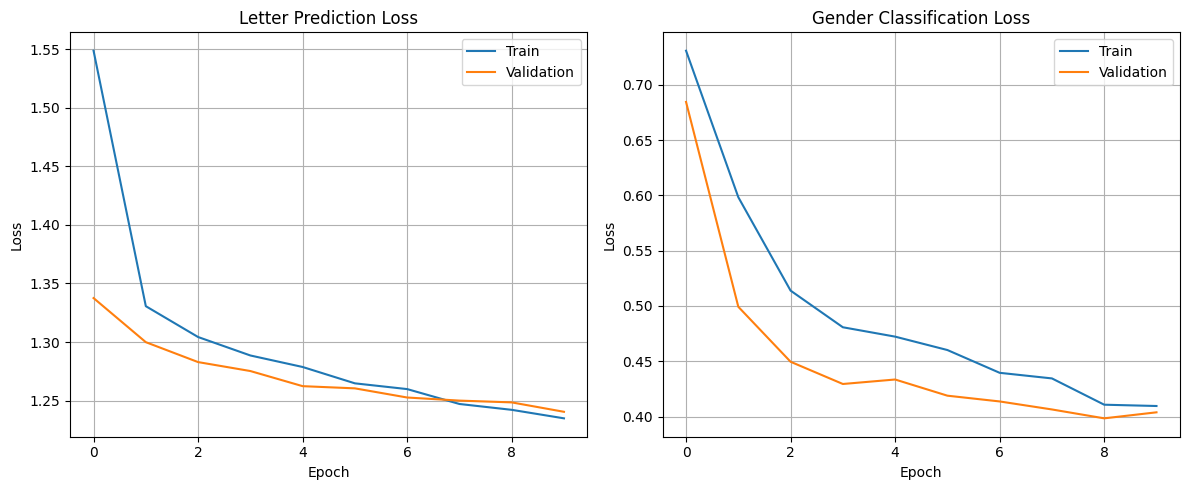

In [224]:
# LSTM
set_seed(21)
model_lstm = NameGeneratorClassifier(config.vocab_size,
                                     config.embed_dim,
                                     config.hidden_size,
                                     config.dropout_prob,
                                     rnn_class=nn.LSTM,
                                     batch_first=True)
train_losses_letter, train_losses_gender, val_losses_letter, val_losses_gender = train_multitask(model_lstm, train_loader, val_loader, num_epochs=10)

In [225]:
lstm_list = new_names(model_lstm)
lstm_list

['arrie', 'mira', 'elarie', 'arie', 'diana', 'ranie', 'emarlie']

In [226]:
lstm_roc_auc = calc_roc_auc(model_lstm, test_loader)

Test ROC AUC: 0.9031


- Сопоставимые метрики с моими имплементациями при одинаковых параметрах запуска.

### Optuna

In [ ]:
//

In [227]:
!pip -q install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.7 MB/s eta 0:00:00


In [228]:
import optuna
from optuna.trial import Trial
import copy

In [ ]:
def train_val_loop_optuna_auc(model, train_loader, val_loader, criterion, optimizer,
                              num_epochs, scheduler=None, trial=None,
                              early_stopping_patience=5, early_stopping_delta=1e-4, seed=None):
    if seed is not None:
      set_seed(seed)
    device = config.device
    best_auc = 0.0
    best_model_state = None
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        total_train = 0.0
        num_batches = 0

        for batch_seq, batch_gender in train_loader:
            batch_seq = batch_seq.to(device)
            batch_gender = batch_gender.to(device).float()
            if batch_gender.dim() == 1:
                batch_gender = batch_gender.unsqueeze(-1)

            optimizer.zero_grad()
            _, gender_prob = model(batch_seq)

            loss = criterion(gender_prob, batch_gender)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train += loss.item()
            num_batches += 1

        avg_train_loss = total_train / num_batches

        model.eval()
        total_val = 0.0
        num_val_batches = 0
        all_probs = []
        all_targets = []

        with torch.no_grad():
            for batch_seq, batch_gender in val_loader:
                batch_seq = batch_seq.to(device)
                batch_gender = batch_gender.to(device).float()
                if batch_gender.dim() == 1:
                    batch_gender = batch_gender.unsqueeze(-1)

                _, gender_prob = model(batch_seq)
                loss = criterion(gender_prob, batch_gender)

                total_val += loss.item()
                num_val_batches += 1

                all_probs.append(gender_prob.cpu().numpy().flatten())
                all_targets.append(batch_gender.cpu().numpy().flatten())

        avg_val_loss = total_val / num_val_batches
        all_probs = np.concatenate(all_probs)
        all_targets = np.concatenate(all_targets).astype(int)
        val_auc = roc_auc_score(all_targets, all_probs)

        if scheduler is not None:
            scheduler.step(avg_val_loss)


        if val_auc > best_auc + early_stopping_delta:
            best_auc = val_auc
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | '
              f'Val Loss: {avg_val_loss:.4f} | Val AUC: {val_auc:.4f} | Best AUC: {best_auc:.4f}')


        if trial is not None:
            trial.report(val_auc, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break


    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        model.eval()
        temp_auc = calc_roc_auc(model, val_loader)
        print(f"DEBUG: After loading best model, AUC = {temp_auc:.6f}, expected best = {best_auc:.6f}")
    else:
        best_auc = val_auc

    return best_auc

In [ ]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    dropout_prob = trial.suggest_float('dropout_prob', 0.0, 0.6)
    embed_dim = trial.suggest_categorical('embed_dim', [32, 64, 128, 256])
    hidden_size = trial.suggest_categorical('hidden_size', [32, 64, 128, 256, 512])
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    seed = trial.suggest_categorical('seed', [21, 42, 158, 97, 21000])


    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)


    model = NameGeneratorClassifier(
        vocab_size=config.vocab_size,
        embed_dim=embed_dim,
        hidden_size=hidden_size,
        dropout_prob=dropout_prob,
        rnn_class=nn.GRU,
        batch_first=True,
        ).to(config.device)

    criterion = nn.BCELoss(reduction='mean')

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=config.patience, factor=config.factor
    )


    early_stopping_patience = 5
    early_stopping_delta = 1e-4


    best_auc = train_val_loop_optuna_auc(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=100, scheduler=scheduler, trial=trial,
        early_stopping_patience=early_stopping_patience,
        early_stopping_delta=early_stopping_delta,
        seed=seed
    )

    model.eval()
    val_auc_check = calc_roc_auc(model, val_loader)
    print(f"Objective internal check: AUC = {val_auc_check:.6f}, best_auc from loop = {best_auc:.6f}")
    if abs(val_auc_check - best_auc) > 1e-6:
        print("WARNING: AUC mismatch inside objective!")

    model.cpu()
    trial.set_user_attr("model_state_dict", model.state_dict())

    return best_auc

- nnLSTM Best trial:
{'lr': 0.0012568560678327665, 'weight_decay': 0.0003001280778161866, 'dropout_prob': 0.3374009183570827, 'embed_dim': 256, 'hidden_size': 512, 'batch_size': 64}
Best AUC: 0.9063240448822135

- nnGRU Best trial:
{'lr': 0.0023594929033177925, 'weight_decay': 1.0198002873064103e-05, 'dropout_prob': 0.5708014310443936, 'embed_dim': 256, 'hidden_size': 128, 'batch_size': 32}
Best AUC: 0.9122242457077085

- MyLSTM Best trial:
{'lr': 0.00702277218078245, 'weight_decay': 1.4703013003532668e-05, 'dropout_prob': 0.5834708680511815, 'embed_dim': 128, 'hidden_size': 256, 'batch_size': 64}
Best AUC: 0.9090796839881375

- MyGRU Best trial:
{'lr': 0.0011721009543086748, 'weight_decay': 3.5951367272269836e-05, 'dropout_prob': 0.339446769054228, 'embed_dim': 128, 'hidden_size': 128, 'batch_size': 32}
Best AUC: 0.9082169829178659

In [237]:
if best_model_state is not None:
    best_model = NameGeneratorClassifier(
        vocab_size=config.vocab_size,
        embed_dim=best_params['embed_dim'],
        hidden_size=best_params['hidden_size'],
        dropout_prob=best_params['dropout_prob'],
        rnn_class=MyGRU,
        #batch_first=True
        )
    best_model.load_state_dict(best_model_state)
    best_model.to(config.device)

In [238]:
checkpoint = {
    'model_state_dict': best_model_state,
    'hyperparameters': best_params,
    'vocab_size': config.vocab_size,
    'rnn_class': 'MyGRU',
    'batch_first': True
}
torch.save(checkpoint, 'best_model_MyGRU.pth')